# 02 - HSE 2018 Preprocess

Step-by-step: load SPSS, inspect columns, map variables, derive GHQ-12 and PGSI placeholders, and save analysis-ready outputs.

In [1]:
# === HSE • Section A — Load raw .sav, extract variable dictionary, save raw parquet ===
import pandas as pd
import pyreadstat
from pathlib import Path
from IPython.display import display

# --- Setup paths ---
PROJECT_ROOT = Path("C:/Users/User/Documents/Github/Gambling_MentalHealth_MSc")
DATA_RAW_HSE = PROJECT_ROOT / "data" / "raw" / "HSE"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

DATA_INTERIM.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# --- Locate HSE 2018 .sav (correct file name) ---
HSE_SAV = DATA_RAW_HSE / "hse_2018.sav"
assert HSE_SAV.exists(), f"HSE SPSS file not found → {HSE_SAV}"

print("Loading HSE 2018 SPSS metadata…")

# --- Load metadata only ---
_, meta = pyreadstat.read_sav(str(HSE_SAV), metadataonly=True)

column_names = meta.column_names
column_labels = meta.column_labels

print(f"\n=== HSE 2018 • Raw Variable Structure ===")
print(f"Total columns: {len(column_names)}")
print(f"Expected respondents (rows): {meta.number_rows}\n")

# --- Build variable dictionary (for your dissertation appendix) ---
hse_dict = pd.DataFrame({
    "variable_name": column_names,
    "description": column_labels
})

dict_path = DATA_INTERIM / "hse_2018_variable_dictionary.csv"
hse_dict.to_csv(dict_path, index=False)
print(f"Variable dictionary saved → {dict_path}")

print("\n=== First 20 Variables (Name + Meaning) ===")
display(hse_dict.head(20))

# --- Load the full HSE dataset (once only) ---
print("\nLoading full HSE dataset…")
df_hse, _ = pyreadstat.read_sav(str(HSE_SAV))

print(f"Loaded → {df_hse.shape[0]} rows × {df_hse.shape[1]} columns")

# --- Save raw dataset to Parquet for fast & consistent use ---
raw_parquet = DATA_INTERIM / "hse_2018_raw.parquet"
df_hse.to_parquet(raw_parquet, index=False)
print(f"Saved raw Parquet → {raw_parquet}")

# Preview sample rows
print("\n=== HSE 2018 Raw Preview (first 10 rows) ===")
display(df_hse.head(10))


Loading HSE 2018 SPSS metadata…

=== HSE 2018 • Raw Variable Structure ===
Total columns: 1591
Expected respondents (rows): 10250

Variable dictionary saved → C:\Users\User\Documents\Github\Gambling_MentalHealth_MSc\data\interim\hse_2018_variable_dictionary.csv

=== First 20 Variables (Name + Meaning) ===


,variable_name,description
0,Seriala,Archive respondent serial number
1,HSEYr,(D) Survey year
2,SampType,Sample type
3,FinOutc,Final outcome code
4,hhsize6,"(D) Household Size, 6+"
5,Nofad3,"(D) Number of adults, top coded 3+"
6,Nofch3,"(D) Number of children, top coded 3+"
7,Qrtint,(D) Quarter of year of individual interview
8,intdayw,(D) Weekday of individual interview
9,IndOut,Individual outcome code



Loading full HSE dataset…
Loaded → 10250 rows × 1591 columns
Saved raw Parquet → C:\Users\User\Documents\Github\Gambling_MentalHealth_MSc\data\interim\hse_2018_raw.parquet

=== HSE 2018 Raw Preview (first 10 rows) ===


,Seriala,HSEYr,SampType,FinOutc,hhsize6,Nofad3,Nofch3,Qrtint,intdayw,IndOut,...,PSU_SCR,Cluster195,Cluster95,Cluster48,wt_int,wt_nurse,wt_sc,wt_probgam,wt_blood,wt_cotinine
0,2811527.0,2018.0,1.0,110.0,1.0,1.0,0.0,1.0,6.0,110.0,...,2181505.0,218211.0,218105.0,218706.0,0.827608,0.704973,0.763393,0.781099,0.787373,NaN
1,2804238.0,2018.0,1.0,110.0,1.0,1.0,0.0,1.0,5.0,110.0,...,2181505.0,218211.0,218105.0,218706.0,0.807912,0.655432,0.741788,0.779406,0.615612,NaN
2,2808193.0,2018.0,1.0,110.0,2.0,2.0,0.0,1.0,2.0,110.0,...,2181505.0,218211.0,218105.0,218706.0,1.084289,0.868472,1.098222,1.164414,NaN,NaN
3,2807643.0,2018.0,1.0,110.0,2.0,2.0,0.0,1.0,2.0,110.0,...,2181505.0,218211.0,218105.0,218706.0,0.961400,0.786779,0.896711,0.995665,NaN,NaN
4,2803796.0,2018.0,1.0,110.0,3.0,2.0,1.0,1.0,3.0,110.0,...,2181505.0,218211.0,218105.0,218706.0,1.203303,1.120884,1.118913,1.106583,1.144427,NaN
5,2806132.0,2018.0,1.0,110.0,3.0,2.0,1.0,1.0,3.0,110.0,...,2181505.0,218211.0,218105.0,218706.0,1.089260,0.928472,1.002870,NaN,0.835545,NaN
6,2809499.0,2018.0,1.0,110.0,3.0,2.0,1.0,1.0,3.0,110.0,...,2181505.0,218211.0,218105.0,218706.0,1.176660,1.058775,NaN,NaN,NaN,0.898849
7,2804411.0,2018.0,1.0,110.0,4.0,3.0,1.0,1.0,2.0,110.0,...,2181505.0,218211.0,218105.0,218706.0,1.932812,2.114481,1.912227,1.906690,NaN,NaN
8,2811218.0,2018.0,1.0,110.0,4.0,3.0,1.0,1.0,2.0,110.0,...,2181505.0,218211.0,218105.0,218706.0,1.346151,1.383274,1.331403,1.433370,1.267776,NaN
9,2806649.0,2018.0,1.0,110.0,4.0,3.0,1.0,1.0,2.0,110.0,...,2181505.0,218211.0,218105.0,218706.0,1.388152,1.834238,1.401646,NaN,NaN,NaN


In [2]:
# === HSE • Section B — Standardise with raw/clean/label structure (MODEL-READY) ===
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("C:/Users/User/Documents/Github/Gambling_MentalHealth_MSc")
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_MODEL   = PROJECT_ROOT / "data" / "processed" / "model-ready"
DATA_MODEL.mkdir(parents=True, exist_ok=True)

# Load raw
df = pd.read_parquet(DATA_INTERIM / "hse_2018_raw.parquet")
print(f"Loaded raw HSE → {df.shape}")

# 1) keep these variables (note: age16g5 not Age35g)
HSE_VARS = [
    "Seriala","HSEYr","Sex","age16g5","origin2","HHINC3","nssec8",
    "GHQ12Scr","PGSIsc","probgam","onlinegam","BMI",
]
missing = [c for c in HSE_VARS if c not in df.columns]
if missing:
    raise KeyError(f"Missing expected HSE columns: {missing}")

df = df[HSE_VARS].copy()

# 2) special codes
NEG = {-9:"refused", -8:"don't know", -1:"not applicable"}

def make_clean(s, mp):
    return s.map(lambda x: mp.get(x) if x in mp else None)

def make_label(s):
    return s.map(lambda x: NEG[x] if x in NEG else "observed")

# 3) raw / clean / label variables
# Sex
df["Sex_clean"]  = make_clean(df["Sex"], {1:"male", 2:"female"})
df["Sex_label"]  = make_label(df["Sex"])

# Age 16+ 5-year bands
age_map = {
    1:"16–19",2:"20–24",3:"25–29",4:"30–34",5:"35–39",
    6:"40–44",7:"45–49",8:"50–54",9:"55–59",10:"60–64",
    11:"65–69",12:"70–74",13:"75–79",14:"80–84",15:"85+"
}
df["age16g5_clean"] = make_clean(df["age16g5"], age_map)
df["age16g5_label"] = make_label(df["age16g5"])

# Ethnicity
df["origin2_clean"] = make_clean(
    df["origin2"], {1:"White",2:"Mixed",3:"Asian",4:"Black",5:"Other"}
)
df["origin2_label"] = make_label(df["origin2"])

# Household income
df["HHINC3_clean"]  = make_clean(df["HHINC3"], {1:"low",2:"medium",3:"high"})
df["HHINC3_label"]  = make_label(df["HHINC3"])

# NS-SEC
nssec_map = {
    1:"higher_managerial",2:"lower_managerial",3:"intermediate",
    4:"small_employers",5:"lower_supervisory",6:"semi_routine",
    7:"routine",8:"never_worked",99:"other"
}
df["nssec8_clean"]  = make_clean(df["nssec8"], nssec_map)
df["nssec8_label"]  = make_label(df["nssec8"])

# GHQ-12 (continuous)
df["GHQ12Scr_clean"] = df["GHQ12Scr"].where(~df["GHQ12Scr"].isin(NEG), None)
df["GHQ12Scr_label"] = make_label(df["GHQ12Scr"])

# =========================
# PGSI — STANDARDISED HERE
# =========================

def pgsi_band(x):
    if pd.isna(x):
        return None
    try:
        x = float(x)
    except:
        return None
    if x == 0:
        return "No risk"
    if 1 <= x <= 2:
        return "Low risk"
    if 3 <= x <= 7:
        return "Moderate risk"
    if x >= 8:
        return "Problem gambling"
    return None

# label negatives
df["PGSIsc_label"] = make_label(df["PGSIsc"])

# numeric helper
df["PGSIsc_num"] = pd.to_numeric(df["PGSIsc"], errors="coerce")

# categorical PGSI (single source of truth)
df["pgsi_category"] = df["PGSIsc_num"].map(pgsi_band)

# explicit binary outcome
df["problem_gambling"] = (df["pgsi_category"] == "Problem gambling").astype("Int64")

# enforce order
df["pgsi_category"] = pd.Categorical(
    df["pgsi_category"],
    categories=["No risk", "Low risk", "Moderate risk", "Problem gambling"],
    ordered=True
)

df.drop(columns=["PGSIsc_num"], inplace=True)

# =========================

# Problem gambler (survey item), online gambling
df["probgam_clean"]  = make_clean(df["probgam"], {0:"not_problem_gambler",1:"problem_gambler"})
df["probgam_label"]  = make_label(df["probgam"])

df["onlinegam_clean"] = make_clean(df["onlinegam"], {0:"no",1:"yes"})
df["onlinegam_label"] = make_label(df["onlinegam"])

# BMI
df["BMI_clean"]  = df["BMI"].where(~df["BMI"].isin(NEG), None)
df["BMI_label"]  = make_label(df["BMI"])

# 4) order columns raw → clean → label (ensure uniqueness)
ordered = []
for col in HSE_VARS:
    for suffix in ["", "_clean", "_label"]:
        c = f"{col}{suffix}"
        if c in df.columns:
            ordered.append(c)

# add standardised PGSI outputs explicitly
ordered.extend(["pgsi_category", "problem_gambling"])

seen, ordered_unique = set(), []
for c in ordered:
    if c not in seen:
        ordered_unique.append(c)
        seen.add(c)

df = df[ordered_unique]

# 5) save
out_path = DATA_MODEL / "hse_2018_model_ready.parquet"
df.to_parquet(out_path, index=False)

print(f"\nHSE model-ready saved → {out_path}  | shape={df.shape}")
display(df.head(10))


Loaded raw HSE → (10250, 1591)

HSE model-ready saved → C:\Users\User\Documents\Github\Gambling_MentalHealth_MSc\data\processed\model-ready\hse_2018_model_ready.parquet  | shape=(10250, 33)


,Seriala,HSEYr,Sex,Sex_clean,Sex_label,age16g5,age16g5_clean,age16g5_label,origin2,origin2_clean,...,probgam_clean,probgam_label,onlinegam,onlinegam_clean,onlinegam_label,BMI,BMI_clean,BMI_label,pgsi_category,problem_gambling
0,2811527.0,2018.0,2.0,female,observed,12.0,70–74,observed,1.0,White,...,not_problem_gambler,observed,NaN,None,observed,22.852438,22.852438,observed,No risk,0
1,2804238.0,2018.0,1.0,male,observed,12.0,70–74,observed,1.0,White,...,not_problem_gambler,observed,2.0,None,observed,28.901494,28.901494,observed,No risk,0
2,2808193.0,2018.0,1.0,male,observed,11.0,65–69,observed,1.0,White,...,not_problem_gambler,observed,2.0,None,observed,27.957436,27.957436,observed,No risk,0
3,2807643.0,2018.0,2.0,female,observed,11.0,65–69,observed,1.0,White,...,not_problem_gambler,observed,2.0,None,observed,41.396089,41.396089,observed,No risk,0
4,2803796.0,2018.0,1.0,male,observed,9.0,55–59,observed,2.0,Mixed,...,not_problem_gambler,observed,1.0,yes,observed,35.582372,35.582372,observed,No risk,0
5,2806132.0,2018.0,2.0,female,observed,8.0,50–54,observed,1.0,White,...,None,observed,NaN,None,observed,27.749658,27.749658,observed,NaN,0
6,2809499.0,2018.0,1.0,male,observed,NaN,None,observed,4.0,Black,...,None,observed,NaN,None,observed,16.580378,16.580378,observed,NaN,0
7,2804411.0,2018.0,1.0,male,observed,8.0,50–54,observed,3.0,Asian,...,not_problem_gambler,observed,2.0,None,observed,40.058811,40.058811,observed,No risk,0
8,2811218.0,2018.0,2.0,female,observed,8.0,50–54,observed,3.0,Asian,...,not_problem_gambler,observed,2.0,None,observed,23.931015,23.931015,observed,No risk,0
9,2806649.0,2018.0,2.0,female,observed,NaN,None,observed,3.0,Asian,...,None,observed,NaN,None,observed,18.141443,18.141443,observed,NaN,0


In [3]:
# === HSE • Section B — Standardise with raw/clean/label structure (MODEL-READY) ===
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("C:/Users/User/Documents/Github/Gambling_MentalHealth_MSc")
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_MODEL   = PROJECT_ROOT / "data" / "processed" / "model-ready"
DATA_MODEL.mkdir(parents=True, exist_ok=True)

# Load raw
df = pd.read_parquet(DATA_INTERIM / "hse_2018_raw.parquet")
print(f"Loaded raw HSE → {df.shape}")

# 1) keep these variables (note: age16g5 not Age35g)
HSE_VARS = [
    "Seriala","HSEYr","Sex","age16g5","origin2","HHINC3","nssec8",
    "GHQ12Scr","PGSIsc","probgam","onlinegam","BMI",
]
missing = [c for c in HSE_VARS if c not in df.columns]
if missing:
    raise KeyError(f"Missing expected HSE columns: {missing}")

df = df[HSE_VARS].copy()

# 2) special codes
NEG = {-9:"refused", -8:"don't know", -1:"not applicable"}

def make_clean(s, mp):
    return s.map(lambda x: mp.get(x) if x in mp else None)

def make_label(s):
    return s.map(lambda x: NEG[x] if x in NEG else "observed")

# 3) raw / clean / label
# Sex
df["Sex_clean"]  = make_clean(df["Sex"], {1:"male", 2:"female"})
df["Sex_label"]  = make_label(df["Sex"])

# Age 16+ 5-year bands
age_map = {
    1:"16–19",2:"20–24",3:"25–29",4:"30–34",5:"35–39",
    6:"40–44",7:"45–49",8:"50–54",9:"55–59",10:"60–64",
    11:"65–69",12:"70–74",13:"75–79",14:"80–84",15:"85+"
}
df["age16g5_clean"] = make_clean(df["age16g5"], age_map)
df["age16g5_label"] = make_label(df["age16g5"])

# Ethnicity
df["origin2_clean"] = make_clean(
    df["origin2"], {1:"White",2:"Mixed",3:"Asian",4:"Black",5:"Other"}
)
df["origin2_label"] = make_label(df["origin2"])

# Household income
df["HHINC3_clean"]  = make_clean(df["HHINC3"], {1:"low",2:"medium",3:"high"})
df["HHINC3_label"]  = make_label(df["HHINC3"])

# NS-SEC
nssec_map = {
    1:"higher_managerial",2:"lower_managerial",3:"intermediate",
    4:"small_employers",5:"lower_supervisory",6:"semi_routine",
    7:"routine",8:"never_worked",99:"other"
}
df["nssec8_clean"]  = make_clean(df["nssec8"], nssec_map)
df["nssec8_label"]  = make_label(df["nssec8"])

# GHQ-12 (continuous)
df["GHQ12Scr_clean"] = df["GHQ12Scr"].where(~df["GHQ12Scr"].isin(NEG), None)
df["GHQ12Scr_label"] = make_label(df["GHQ12Scr"])

# =========================
# PGSI — STANDARDISED HERE
# =========================
def pgsi_band(x):
    if pd.isna(x):
        return None
    try:
        x = float(x)
    except:
        return None
    if x == 0:
        return "No risk"
    if 1 <= x <= 2:
        return "Low risk"
    if 3 <= x <= 7:
        return "Moderate risk"
    if x >= 8:
        return "Problem gambling"
    return None

# label negatives
df["PGSIsc_label"] = make_label(df["PGSIsc"])

# numeric helper
df["PGSIsc_num"] = pd.to_numeric(df["PGSIsc"], errors="coerce")

# categorical PGSI (single source of truth)
df["pgsi_category"] = df["PGSIsc_num"].map(pgsi_band)

# explicit binary outcome derived from PGSI
df["problem_gambling"] = (df["pgsi_category"] == "Problem gambling").astype("Int64")

# enforce category order
df["pgsi_category"] = pd.Categorical(
    df["pgsi_category"],
    categories=["No risk", "Low risk", "Moderate risk", "Problem gambling"],
    ordered=True
)

df.drop(columns=["PGSIsc_num"], inplace=True)
# =========================

# Problem gambler (survey item), online gambling
df["probgam_clean"]  = make_clean(df["probgam"], {0:"not_problem_gambler",1:"problem_gambler"})
df["probgam_label"]  = make_label(df["probgam"])

df["onlinegam_clean"] = make_clean(df["onlinegam"], {0:"no",1:"yes"})
df["onlinegam_label"] = make_label(df["onlinegam"])

# BMI (continuous)
df["BMI_clean"]  = df["BMI"].where(~df["BMI"].isin(NEG), None)
df["BMI_label"]  = make_label(df["BMI"])

# 4) order columns raw → clean → label (ensure uniqueness)
ordered = []
for col in HSE_VARS:
    for suffix in ["", "_clean", "_label"]:
        c = f"{col}{suffix}"
        if c in df.columns:
            ordered.append(c)

# explicitly include standardised PGSI outputs
ordered.extend(["pgsi_category", "problem_gambling"])

# de-duplicate while preserving order (prevents Parquet error)
seen, ordered_unique = set(), []
for c in ordered:
    if c not in seen:
        ordered_unique.append(c)
        seen.add(c)

df = df[ordered_unique]

# 5) save
out_path = DATA_MODEL / "hse_2018_model_ready.parquet"
df.to_parquet(out_path, index=False)

print(f"\nHSE model-ready saved → {out_path}  | shape={df.shape}")
display(df.head(10))


Loaded raw HSE → (10250, 1591)

HSE model-ready saved → C:\Users\User\Documents\Github\Gambling_MentalHealth_MSc\data\processed\model-ready\hse_2018_model_ready.parquet  | shape=(10250, 33)


,Seriala,HSEYr,Sex,Sex_clean,Sex_label,age16g5,age16g5_clean,age16g5_label,origin2,origin2_clean,...,probgam_clean,probgam_label,onlinegam,onlinegam_clean,onlinegam_label,BMI,BMI_clean,BMI_label,pgsi_category,problem_gambling
0,2811527.0,2018.0,2.0,female,observed,12.0,70–74,observed,1.0,White,...,not_problem_gambler,observed,NaN,None,observed,22.852438,22.852438,observed,No risk,0
1,2804238.0,2018.0,1.0,male,observed,12.0,70–74,observed,1.0,White,...,not_problem_gambler,observed,2.0,None,observed,28.901494,28.901494,observed,No risk,0
2,2808193.0,2018.0,1.0,male,observed,11.0,65–69,observed,1.0,White,...,not_problem_gambler,observed,2.0,None,observed,27.957436,27.957436,observed,No risk,0
3,2807643.0,2018.0,2.0,female,observed,11.0,65–69,observed,1.0,White,...,not_problem_gambler,observed,2.0,None,observed,41.396089,41.396089,observed,No risk,0
4,2803796.0,2018.0,1.0,male,observed,9.0,55–59,observed,2.0,Mixed,...,not_problem_gambler,observed,1.0,yes,observed,35.582372,35.582372,observed,No risk,0
5,2806132.0,2018.0,2.0,female,observed,8.0,50–54,observed,1.0,White,...,None,observed,NaN,None,observed,27.749658,27.749658,observed,NaN,0
6,2809499.0,2018.0,1.0,male,observed,NaN,None,observed,4.0,Black,...,None,observed,NaN,None,observed,16.580378,16.580378,observed,NaN,0
7,2804411.0,2018.0,1.0,male,observed,8.0,50–54,observed,3.0,Asian,...,not_problem_gambler,observed,2.0,None,observed,40.058811,40.058811,observed,No risk,0
8,2811218.0,2018.0,2.0,female,observed,8.0,50–54,observed,3.0,Asian,...,not_problem_gambler,observed,2.0,None,observed,23.931015,23.931015,observed,No risk,0
9,2806649.0,2018.0,2.0,female,observed,NaN,None,observed,3.0,Asian,...,None,observed,NaN,None,observed,18.141443,18.141443,observed,NaN,0


## Save analysis-ready outputs and preview

In [4]:
# === HSE • Section C — Create Analysis-Ready Dataset ===
import pandas as pd
from pathlib import Path
  
PROJECT_ROOT   = Path("C:/Users/User/Documents/Github/Gambling_MentalHealth_MSc")
DATA_MODEL     = PROJECT_ROOT / "data" / "processed" / "model-ready"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed" / "analysis-ready"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Load model-ready data
df = pd.read_parquet(DATA_MODEL / "hse_2018_model_ready.parquet")
print(f"Loaded model-ready HSE → {df.shape}")

# ----------------------------------
# Rename columns to analysis-ready
# ----------------------------------
rename_map = {
    "Seriala": "participant_id",
    "HSEYr": "survey_year",

    "Sex_clean": "sex",
    "Sex_label": "sex_label",

    "age16g5_clean": "age_group",
    "age16g5_label": "age_group_label",

    "origin2_clean": "ethnicity",
    "origin2_label": "ethnicity_label",

    "HHINC3_clean": "income_group",
    "HHINC3_label": "income_group_label",

    "nssec8_clean": "social_class",
    "nssec8_label": "social_class_label",

    "GHQ12Scr_clean": "ghq12_score",
    "GHQ12Scr_label": "ghq12_label",

    # PGSI (standardised in Section B)
    "PGSIsc": "pgsi_score",                 # continuous score
    "pgsi_category": "pgsi_category",       # categorical risk band
    "PGSIsc_label": "pgsi_code_label",      # special code meaning

    # Gambling behaviour
    "problem_gambling": "problem_gambling", # binary from PGSI
    "probgam_label": "problem_gambling_label",

    "onlinegam_clean": "online_gambling",
    "onlinegam_label": "online_gambling_label",

    # BMI
    "BMI_clean": "bmi",
    "BMI_label": "bmi_label",
}

df = df.rename(columns=rename_map)

# ----------------------------------
# Drop raw variables no longer needed
# ----------------------------------
raw_cols = [
    "Sex","age16g5","origin2","HHINC3","nssec8",
    "GHQ12Scr","PGSIsc","probgam","onlinegam","BMI"
]

# Keep renamed pgsi_score (formerly PGSIsc)
raw_cols = [c for c in raw_cols if c not in ["PGSIsc"]]

df.drop(columns=[c for c in raw_cols if c in df.columns],
        inplace=True,
        errors="ignore")

# ----------------------------------
# Logical column order (analysis-ready)
# ----------------------------------
ordered_columns = [
    "participant_id","survey_year",

    "sex","sex_label",
    "age_group","age_group_label",
    "ethnicity","ethnicity_label",
    "income_group","income_group_label",
    "social_class","social_class_label",

    "ghq12_score","ghq12_label",

    "pgsi_score","pgsi_category","pgsi_code_label",
    "problem_gambling","problem_gambling_label",

    "online_gambling","online_gambling_label",

    "bmi","bmi_label",
]

df = df[[c for c in ordered_columns if c in df.columns]]

# ----------------------------------
# Save analysis-ready dataset
# ----------------------------------
out_path = DATA_PROCESSED / "hse_2018_analysis_ready.parquet"
df.to_parquet(out_path, index=False)

print(f"HSE analysis-ready saved → {out_path}")
print(f"Final shape: {df.shape}")

# Preview
display(df.head(10))


Loaded model-ready HSE → (10250, 33)
HSE analysis-ready saved → C:\Users\User\Documents\Github\Gambling_MentalHealth_MSc\data\processed\analysis-ready\hse_2018_analysis_ready.parquet
Final shape: (10250, 23)


,participant_id,survey_year,sex,sex_label,age_group,age_group_label,ethnicity,ethnicity_label,income_group,income_group_label,...,ghq12_label,pgsi_score,pgsi_category,pgsi_code_label,problem_gambling,problem_gambling_label,online_gambling,online_gambling_label,bmi,bmi_label
0,2811527.0,2018.0,female,observed,70–74,observed,White,observed,None,observed,...,observed,0.0,No risk,observed,0,observed,None,observed,22.852438,observed
1,2804238.0,2018.0,male,observed,70–74,observed,White,observed,None,observed,...,observed,0.0,No risk,observed,0,observed,None,observed,28.901494,observed
2,2808193.0,2018.0,male,observed,65–69,observed,White,observed,None,observed,...,observed,0.0,No risk,observed,0,observed,None,observed,27.957436,observed
3,2807643.0,2018.0,female,observed,65–69,observed,White,observed,None,observed,...,observed,0.0,No risk,observed,0,observed,None,observed,41.396089,observed
4,2803796.0,2018.0,male,observed,55–59,observed,Mixed,observed,None,observed,...,observed,0.0,No risk,observed,0,observed,yes,observed,35.582372,observed
5,2806132.0,2018.0,female,observed,50–54,observed,White,observed,None,observed,...,observed,NaN,NaN,observed,0,observed,None,observed,27.749658,observed
6,2809499.0,2018.0,male,observed,None,observed,Black,observed,None,observed,...,observed,NaN,NaN,observed,0,observed,None,observed,16.580378,observed
7,2804411.0,2018.0,male,observed,50–54,observed,Asian,observed,None,observed,...,observed,0.0,No risk,observed,0,observed,None,observed,40.058811,observed
8,2811218.0,2018.0,female,observed,50–54,observed,Asian,observed,None,observed,...,observed,0.0,No risk,observed,0,observed,None,observed,23.931015,observed
9,2806649.0,2018.0,female,observed,None,observed,Asian,observed,None,observed,...,observed,NaN,NaN,observed,0,observed,None,observed,18.141443,observed


# HSE • Section D —  EDA 

In [5]:
# === HSE • Section D — Exploration & Validation (Analysis-Ready EDA) ===
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from pathlib import Path

# ------------------------------------------------------------
# D0. Load analysis-ready dataset
# ------------------------------------------------------------
PROJECT_ROOT = Path("C:/Users/User/Documents/Github/Gambling_MentalHealth_MSc")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed" / "analysis-ready"

df = pd.read_parquet(DATA_PROCESSED / "hse_2018_analysis_ready.parquet")

print(f"Loaded HSE analysis-ready → {df.shape}")
display(df.head(10))

Loaded HSE analysis-ready → (10250, 23)


,participant_id,survey_year,sex,sex_label,age_group,age_group_label,ethnicity,ethnicity_label,income_group,income_group_label,...,ghq12_label,pgsi_score,pgsi_category,pgsi_code_label,problem_gambling,problem_gambling_label,online_gambling,online_gambling_label,bmi,bmi_label
0,2811527.0,2018.0,female,observed,70–74,observed,White,observed,None,observed,...,observed,0.0,No risk,observed,0,observed,None,observed,22.852438,observed
1,2804238.0,2018.0,male,observed,70–74,observed,White,observed,None,observed,...,observed,0.0,No risk,observed,0,observed,None,observed,28.901494,observed
2,2808193.0,2018.0,male,observed,65–69,observed,White,observed,None,observed,...,observed,0.0,No risk,observed,0,observed,None,observed,27.957436,observed
3,2807643.0,2018.0,female,observed,65–69,observed,White,observed,None,observed,...,observed,0.0,No risk,observed,0,observed,None,observed,41.396089,observed
4,2803796.0,2018.0,male,observed,55–59,observed,Mixed,observed,None,observed,...,observed,0.0,No risk,observed,0,observed,yes,observed,35.582372,observed
5,2806132.0,2018.0,female,observed,50–54,observed,White,observed,None,observed,...,observed,NaN,NaN,observed,0,observed,None,observed,27.749658,observed
6,2809499.0,2018.0,male,observed,None,observed,Black,observed,None,observed,...,observed,NaN,NaN,observed,0,observed,None,observed,16.580378,observed
7,2804411.0,2018.0,male,observed,50–54,observed,Asian,observed,None,observed,...,observed,0.0,No risk,observed,0,observed,None,observed,40.058811,observed
8,2811218.0,2018.0,female,observed,50–54,observed,Asian,observed,None,observed,...,observed,0.0,No risk,observed,0,observed,None,observed,23.931015,observed
9,2806649.0,2018.0,female,observed,None,observed,Asian,observed,None,observed,...,observed,NaN,NaN,observed,0,observed,None,observed,18.141443,observed


In [6]:
# ------------------------------------------------------------
# D1. Overview of variables and data coverage
# ------------------------------------------------------------
summary = pd.DataFrame({
    "variable": df.columns,
    "data_type": df.dtypes.astype(str),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)

display(summary)

# Define logical order for age groups
age_order = [
    "16–19", "20–24", "25–29", "30–34", "35–39",
    "40–44", "45–49", "50–54", "55–59", "60–64",
    "65–69", "70–74", "75–79", "80–84", "85+"
]

# Apply ordered categorical type (no data change)
if "age_group" in df.columns:
    df["age_group"] = pd.Categorical(
        df["age_group"],
        categories=age_order,
        ordered=True
    )

print("\nKey categorical variables:")
for col in ["sex", "age_group", "income_group", "pgsi_category", "problem_gambling"]:
    if col in df.columns:
        print(f"\n{col}")

        # Age group: sort by logical order
        if col == "age_group":
            print(
                df[col]
                .value_counts(dropna=False)
                .sort_index()
            )
        else:
            # Other variables: default behaviour
            print(df[col].value_counts(dropna=False))


,variable,data_type,missing_percent
income_group,income_group,object,98.84
online_gambling,online_gambling,object,94.16
pgsi_category,pgsi_category,category,32.46
pgsi_score,pgsi_score,float64,32.46
ghq12_score,ghq12_score,float64,26.80
age_group,age_group,object,22.51
social_class,social_class,object,21.84
bmi,bmi,float64,19.33
ethnicity,ethnicity,object,0.31
age_group_label,age_group_label,object,0.00



Key categorical variables:

sex
sex
female    5562
male      4688
Name: count, dtype: int64

age_group
age_group
16–19     187
20–24     153
25–29     408
30–34     502
35–39     652
40–44     661
45–49     633
50–54     681
55–59     705
60–64     710
65–69     632
70–74     688
75–79     637
80–84     418
85+       276
NaN      2307
Name: count, dtype: int64

income_group
income_group
None      10131
low          62
medium       33
high         24
Name: count, dtype: int64

pgsi_category
pgsi_category
No risk             6684
NaN                 3327
Low risk             164
Moderate risk         52
Problem gambling      23
Name: count, dtype: int64

problem_gambling
problem_gambling
0    10227
1       23
Name: count, dtype: Int64


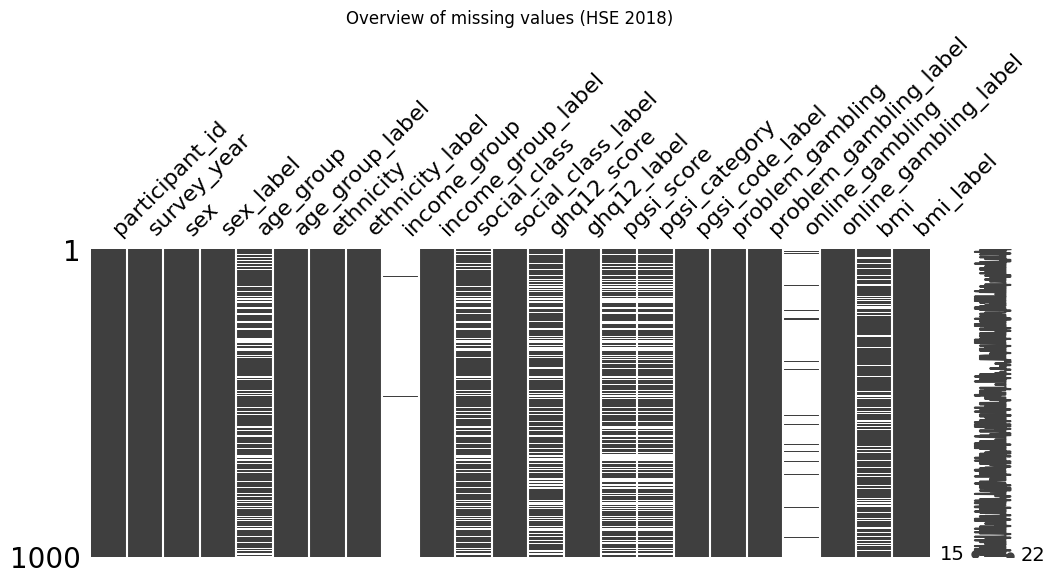

In [7]:
# ------------------------------------------------------------
# D2. Missing values overview
# ------------------------------------------------------------
# This step checks how much information is missing across variables.
# No values are removed or replaced at this stage.

msno.matrix(df.sample(min(1000, len(df))), figsize=(12, 4))
plt.title("Overview of missing values (HSE 2018)")
plt.show()


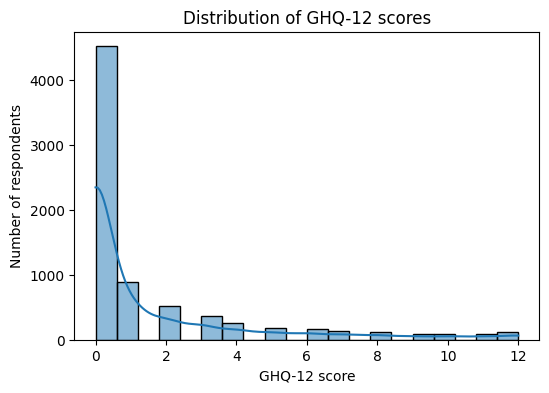

count    7503.000000
mean        1.565907
std         2.801891
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max        12.000000
Name: ghq12_score, dtype: float64

In [8]:
# ------------------------------------------------------------
# D3. Distribution of GHQ-12 scores
# ------------------------------------------------------------
plt.figure(figsize=(6, 4))
sns.histplot(df["ghq12_score"].dropna(), bins=20, kde=True)
plt.title("Distribution of GHQ-12 scores")
plt.xlabel("GHQ-12 score")
plt.ylabel("Number of respondents")
plt.show()

df["ghq12_score"].describe()


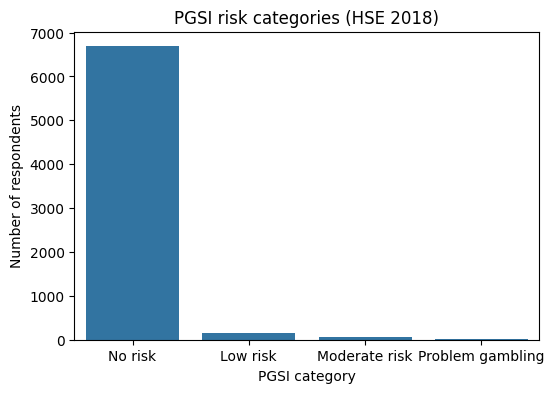

C:\Users\User\AppData\Local\Temp\ipykernel_23376\2709213053.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("pgsi_category")["pgsi_score"]


,count,mean,std,min,25%,50%,75%,max
pgsi_category,,,,,,,,
No risk,6684.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
Low risk,164.0,1.28,0.45,1.0,1.0,1.0,2.0,2.0
Moderate risk,52.0,4.46,1.32,3.0,3.0,4.0,6.0,7.0
Problem gambling,23.0,14.30,6.27,8.0,9.5,12.0,18.0,27.0


In [9]:
# ------------------------------------------------------------
# D4. PGSI distribution and consistency checks
# ------------------------------------------------------------

# PGSI category counts
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x="pgsi_category",
    order=["No risk", "Low risk", "Moderate risk", "Problem gambling"]
)
plt.title("PGSI risk categories (HSE 2018)")
plt.xlabel("PGSI category")
plt.ylabel("Number of respondents")
plt.show()

# Check consistency between PGSI score and category
display(
    df.groupby("pgsi_category")["pgsi_score"]
      .describe()
      .round(2)
)


In [10]:
# ------------------------------------------------------------
# D5. Binary problem gambling check
# ------------------------------------------------------------
# Confirm that the binary outcome matches the PGSI category

pgsi_check = pd.crosstab(df["pgsi_category"], df["problem_gambling"])
display(pgsi_check)

# Logical checks
assert pgsi_check.loc["Problem gambling", 1] > 0, "Problem gambling not flagged correctly"
assert pgsi_check.drop("Problem gambling")[1].sum() == 0, "Non-problem cases misclassified"


problem_gambling,0,1
pgsi_category,,
No risk,6684,0
Low risk,164,0
Moderate risk,52,0
Problem gambling,0,23


In [11]:
# =============================================================
#  pgsi_3cat into HSE analysis-ready dataset
# =============================================================

import pandas as pd

HSE_ANALYSIS_PATH = "data/processed/analysis-ready/hse_2018_analysis_ready.parquet"

# -----------------------------
# Load HSE analysis-ready data
# -----------------------------
hse = pd.read_parquet(HSE_ANALYSIS_PATH)

# -----------------------------
# Create 3-category PGSI variable
# -----------------------------
# Work in string space to allow safe collapsing
pgsi_tmp = hse["pgsi_category"].astype("string")

# Collapse Moderate + Problem into At-risk
pgsi_tmp = pgsi_tmp.replace({
    "Moderate risk": "At-risk gambling",
    "Problem gambling": "At-risk gambling"
})

# Recreate ordered categorical variable
hse["pgsi_3cat"] = pd.Categorical(
    pgsi_tmp,
    categories=["No risk", "Low risk", "At-risk gambling"],
    ordered=True
)

# -----------------------------
# Sanity check
# -----------------------------
print("pgsi_3cat distribution (HSE analysis-ready):")
print(hse["pgsi_3cat"].value_counts(dropna=False).sort_index())

# -----------------------------
# SAVE BACK (THIS WAS MISSING)
# -----------------------------
hse.to_parquet(HSE_ANALYSIS_PATH, index=False)

print("\n✔ pgsi_3cat saved back to:")
print(" →", HSE_ANALYSIS_PATH)


pgsi_3cat distribution (HSE analysis-ready):
pgsi_3cat
No risk             6684
Low risk             164
At-risk gambling      75
NaN                 3327
Name: count, dtype: int64

✔ pgsi_3cat saved back to:
 → data/processed/analysis-ready/hse_2018_analysis_ready.parquet


In [12]:
import pandas as pd
import numpy as np

# -------------------------------------------------------------------
# SECTION E — DESCRIPTIVE PROFILE OF THE HSE 2018 SAMPLE (TABLE 4.1)
# -------------------------------------------------------------------
# df is the HSE 2018 analysis-ready dataset created in Section C
# This section produces Table 4.1 in the dissertation.
# -------------------------------------------------------------------

hse = df.copy()

# ------------------------------------------------------------
# E1. Create GHQ-12 distress indicator (0–3 vs 4+)
# ------------------------------------------------------------
hse["ghq12_score"] = pd.to_numeric(hse["ghq12_score"], errors="coerce")

hse["ghq12_distress"] = (hse["ghq12_score"] >= 4).astype("Int64")
hse["ghq12_distress_clean"] = hse["ghq12_distress"].map({
    0: "Not distressed",
    1: "Distressed"
})

# ------------------------------------------------------------
# E2. Helper function: frequency table with common denominator
# ------------------------------------------------------------
def freq_table_with_labels_total(df, clean_var, label_var, characteristic_label):
    """
    Build a frequency table using:
      - clean_var for observed categories
      - label_var to explain missing values (if available)

    Percentages are calculated using the full sample size
    to match standard reporting in health surveys.
    """
    total_n = df.shape[0]
    rows = []

    # Observed categories
    non_missing = df[clean_var].notna()
    if non_missing.any():
        tab_obs = (
            df.loc[non_missing, clean_var]
              .value_counts()
              .rename_axis("Category")
              .reset_index(name="n")
        )
        tab_obs["%"] = (tab_obs["n"] / total_n) * 100
        tab_obs.insert(0, "Characteristic", characteristic_label)
        rows.append(tab_obs)

    # Missing values explained using label_var
    if label_var is not None:
        missing = df[clean_var].isna()
        if missing.any():
            lab_counts = (
                df.loc[missing, label_var]
                  .value_counts()
                  .rename_axis("Category")
                  .reset_index(name="n")
            )
            lab_counts["Category"] = lab_counts["Category"].replace({
                "refused": "No data (refused)",
                "don't know": "No data (don't know)",
                "not applicable": "No data (not applicable)",
                "observed": "No data (other)"
            })
            lab_counts["%"] = (lab_counts["n"] / total_n) * 100
            lab_counts.insert(0, "Characteristic", characteristic_label)
            rows.append(lab_counts)

    if rows:
        out = pd.concat(rows, ignore_index=True)
        out["%"] = out["%"].round(1)
        return out[["Characteristic", "Category", "n", "%"]]
    else:
        return pd.DataFrame(columns=["Characteristic", "Category", "n", "%"])

# ------------------------------------------------------------
# E3. Build components of Table 4.1
# ------------------------------------------------------------

# Sex
sex_tab = freq_table_with_labels_total(
    hse,
    clean_var="sex",
    label_var="sex_label",
    characteristic_label="Sex"
)

# Age group
age_tab = freq_table_with_labels_total(
    hse,
    clean_var="age_group",
    label_var="age_group_label",
    characteristic_label="Age group"
)

# Household income group
income_tab = freq_table_with_labels_total(
    hse,
    clean_var="income_group",
    label_var="income_group_label",
    characteristic_label="Household income group"
)

# Social class
social_tab = freq_table_with_labels_total(
    hse,
    clean_var="social_class",
    label_var="social_class_label",
    characteristic_label="Social class"
)

# GHQ-12 distress indicator
ghq_tab = freq_table_with_labels_total(
    hse,
    clean_var="ghq12_distress_clean",
    label_var=None,
    characteristic_label="GHQ-12 distress status"
)

# Problem gambling indicator (map to readable labels first)
hse["problem_gambling_clean"] = hse["problem_gambling"].map({
    0: "Not problem gambling",
    1: "Problem gambling"
})

pg_tab = freq_table_with_labels_total(
    hse,
    clean_var="problem_gambling_clean",
    label_var="problem_gambling_label",
    characteristic_label="Problem gambling status"
)

# ------------------------------------------------------------
# E4. Combine into Table 4.1
# ------------------------------------------------------------
table_4_1 = pd.concat(
    [sex_tab, age_tab, income_tab, social_tab, ghq_tab, pg_tab],
    ignore_index=True
)

table_4_1["%"] = table_4_1["%"].round(1)

display(table_4_1)


,Characteristic,Category,n,%
0,Sex,female,5562,54.3
1,Sex,male,4688,45.7
2,Age group,60–64,710,6.9
3,Age group,55–59,705,6.9
4,Age group,70–74,688,6.7
5,Age group,50–54,681,6.6
6,Age group,40–44,661,6.4
7,Age group,35–39,652,6.4
8,Age group,75–79,637,6.2
9,Age group,45–49,633,6.2


In [13]:
import pandas as pd
from pathlib import Path

# Adjust this if your project root path is different
PROJECT_ROOT = Path("C:/Users/User/Documents/Github/Gambling_MentalHealth_MSc")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed" / "analysis-ready"

# ------------------------------------------------------------
# Load HSE analysis-ready file
# ------------------------------------------------------------
hse = pd.read_parquet(DATA_PROCESSED / "hse_2018_analysis_ready.parquet")
print("HSE analysis-ready shape (rows, columns):", hse.shape)

# ------------------------------------------------------------
# Create 3-category PGSI variable for inferential analysis
# (safe collapse, no warnings, no errors)
# ------------------------------------------------------------
pgsi_tmp = hse["pgsi_category"].astype("string")

pgsi_tmp = pgsi_tmp.replace({
    "Moderate risk": "At-risk gambling",
    "Problem gambling": "At-risk gambling"
})

hse["pgsi_3cat"] = pd.Categorical(
    pgsi_tmp,
    categories=["No risk", "Low risk", "At-risk gambling"],
    ordered=True
)

# ------------------------------------------------------------
# Sample size checks (used in Chapter 4 text)
# ------------------------------------------------------------

# 1) Basic n
n_hse_all = len(hse)
print("\nTotal HSE analysis-ready adults:", n_hse_all)

# 2) GHQ-12 availability
n_hse_ghq = hse["ghq12_score"].notna().sum()
print("HSE with non-missing GHQ-12 score:", n_hse_ghq)

# 3) Problem gambling status availability (binary PGSI indicator)
n_hse_pg = hse["problem_gambling"].notna().sum()
print("HSE with non-missing problem_gambling indicator:", n_hse_pg)

# 4) Both GHQ-12 and problem gambling available
n_hse_both = (
    (hse["ghq12_score"].notna()) &
    (hse["problem_gambling"].notna())
).sum()
print("HSE with both GHQ-12 and problem_gambling:", n_hse_both)

# 5) PGSI 3-category availability (for inferential analysis)
n_hse_pgsi3 = hse["pgsi_3cat"].notna().sum()
print("HSE with non-missing pgsi_3cat:", n_hse_pgsi3)

print("\nPGSI 3-category distribution:")
print(hse["pgsi_3cat"].value_counts(dropna=False).sort_index())

# 6) “No data (other)” categories for income and social class
if "income_group_label" in hse.columns:
    n_income_nodata = (hse["income_group_label"] == "No data (other)").sum()
    print("\nIncome_group 'No data (other)':", n_income_nodata)

if "social_class_label" in hse.columns:
    n_class_nodata = (hse["social_class_label"] == "No data (other)").sum()
    print("Social_class 'No data (other)':", n_class_nodata)


HSE analysis-ready shape (rows, columns): (10250, 24)

Total HSE analysis-ready adults: 10250
HSE with non-missing GHQ-12 score: 7503
HSE with non-missing problem_gambling indicator: 10250
HSE with both GHQ-12 and problem_gambling: 7503
HSE with non-missing pgsi_3cat: 6923

PGSI 3-category distribution:
pgsi_3cat
No risk             6684
Low risk             164
At-risk gambling      75
NaN                 3327
Name: count, dtype: int64

Income_group 'No data (other)': 0
Social_class 'No data (other)': 0


In [14]:
import pandas as pd

# Use the HSE analysis-ready dataframe
hse = df.copy()

# ------------------------------------------------------------
# Restrict to respondents with an observed problem gambling value
# ------------------------------------------------------------
mask_obs_pg = hse["problem_gambling_label"] == "observed"
hse_pg = hse.loc[mask_obs_pg].copy()

# ------------------------------------------------------------
# Ensure logical ordering for age groups
# ------------------------------------------------------------
age_order = [
    "16–19", "20–24", "25–29", "30–34", "35–39",
    "40–44", "45–49", "50–54", "55–59", "60–64",
    "65–69", "70–74", "75–79", "80–84", "85+"
]

if "age_group" in hse_pg.columns:
    hse_pg["age_group"] = pd.Categorical(
        hse_pg["age_group"],
        categories=age_order,
        ordered=True
    )

# ------------------------------------------------------------
# Helper: tidy cross-tabulation with row percentages
# ------------------------------------------------------------
def crosstab_pg_by(group_var, group_label):
    tab = (
        hse_pg
        .groupby([group_var, "problem_gambling"], observed=True)
        .size()
        .reset_index(name="n")
    )

    # Human-readable labels
    tab["Problem gambling status"] = tab["problem_gambling"].map({
        0: "Not problem gambling",
        1: "Problem gambling"
    })

    # Row percentages
    totals = (
        tab
        .groupby(group_var, observed=True)["n"]
        .transform("sum")
    )
    tab["%"] = (tab["n"] / totals * 100).round(1)

    tab = tab.rename(columns={group_var: group_label})

    return tab[[group_label, "Problem gambling status", "n", "%"]]

# ------------------------------------------------------------
# Tables (no print banners)
# ------------------------------------------------------------
table_4_2_sex = crosstab_pg_by("sex", "Sex")
display(table_4_2_sex)

table_4_2_age = crosstab_pg_by("age_group", "Age group")
display(table_4_2_age)


,Sex,Problem gambling status,n,%
0,female,Not problem gambling,5556,99.9
1,female,Problem gambling,6,0.1
2,male,Not problem gambling,4671,99.6
3,male,Problem gambling,17,0.4


,Age group,Problem gambling status,n,%
0,16–19,Not problem gambling,187,100.0
1,20–24,Not problem gambling,153,100.0
2,25–29,Not problem gambling,403,98.8
3,25–29,Problem gambling,5,1.2
4,30–34,Not problem gambling,500,99.6
5,30–34,Problem gambling,2,0.4
6,35–39,Not problem gambling,648,99.4
7,35–39,Problem gambling,4,0.6
8,40–44,Not problem gambling,659,99.7
9,40–44,Problem gambling,2,0.3


In [15]:
import pandas as pd

# Use the HSE analysis-ready dataframe
hse = df.copy()

# ------------------------------------------------------------
# Restrict to respondents with an observed problem gambling value
# ------------------------------------------------------------
mask_obs_pg = hse["problem_gambling_label"] == "observed"
hse_pg = hse.loc[mask_obs_pg].copy()

print(f"Analytic n with usable problem gambling status: {hse_pg.shape[0]}")

# ------------------------------------------------------------
# Ensure logical ordering for age groups
# ------------------------------------------------------------
age_order = [
    "16–19", "20–24", "25–29", "30–34", "35–39",
    "40–44", "45–49", "50–54", "55–59", "60–64",
    "65–69", "70–74", "75–79", "80–84", "85+"
]

if "age_group" in hse_pg.columns:
    hse_pg["age_group"] = pd.Categorical(
        hse_pg["age_group"],
        categories=age_order,
        ordered=True
    )

# ------------------------------------------------------------
# Helper: tidy cross-tabulation with row percentages
# ------------------------------------------------------------
def crosstab_pg_by(group_var, group_label):
    tab = (
        hse_pg
        .groupby([group_var, "problem_gambling"])
        .size()
        .reset_index(name="n")
    )

    # Map binary outcome to readable labels
    tab["Problem gambling status"] = tab["problem_gambling"].map({
        0: "Not problem gambling",
        1: "Problem gambling"
    })

    # Total within each group (row percentages)
    totals = tab.groupby(group_var)["n"].transform("sum")
    tab["%"] = (tab["n"] / totals * 100).round(1)

    tab = tab.rename(columns={group_var: group_label})

    return tab[[group_label, "Problem gambling status", "n", "%"]]

# ------------------------------------------------------------
# 4.2.2.a Problem gambling by sex
# ------------------------------------------------------------
table_4_2_sex = crosstab_pg_by("sex", "Sex")
print("\n=== Table 4.2a: Problem gambling status by sex (HSE 2018) ===")
display(table_4_2_sex)

# ------------------------------------------------------------
# 4.2.2.b Problem gambling by age group
# ------------------------------------------------------------
table_4_2_age = crosstab_pg_by("age_group", "Age group")
print("\n=== Table 4.2b: Problem gambling status by age group (HSE 2018) ===")
display(table_4_2_age)


Analytic n with usable problem gambling status: 10250

=== Table 4.2a: Problem gambling status by sex (HSE 2018) ===


,Sex,Problem gambling status,n,%
0,female,Not problem gambling,5556,99.9
1,female,Problem gambling,6,0.1
2,male,Not problem gambling,4671,99.6
3,male,Problem gambling,17,0.4



=== Table 4.2b: Problem gambling status by age group (HSE 2018) ===


C:\Users\User\AppData\Local\Temp\ipykernel_23376\2190222421.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([group_var, "problem_gambling"])
C:\Users\User\AppData\Local\Temp\ipykernel_23376\2190222421.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totals = tab.groupby(group_var)["n"].transform("sum")


,Age group,Problem gambling status,n,%
0,16–19,Not problem gambling,187,100.0
1,16–19,Problem gambling,0,0.0
2,20–24,Not problem gambling,153,100.0
3,20–24,Problem gambling,0,0.0
4,25–29,Not problem gambling,403,98.8
5,25–29,Problem gambling,5,1.2
6,30–34,Not problem gambling,500,99.6
7,30–34,Problem gambling,2,0.4
8,35–39,Not problem gambling,648,99.4
9,35–39,Problem gambling,4,0.6


In [16]:
# ------------------------------------------------------------
# D2. Convert clean numeric columns
# ------------------------------------------------------------
numeric_clean_cols = [
    "ghq12_score",
    "pgsi_score",
    "bmi",
    "participant_id",
    "survey_year"
]

for col in numeric_clean_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Numeric conversion applied to clean numeric columns.")

# ------------------------------------------------------------
# D3. Check data types after conversion
# ------------------------------------------------------------
print("\nData types after numeric conversion:")
print(df.dtypes)
# ------------------------------------------------------------
# D4. Numeric vs categorical variables
# ------------------------------------------------------------
# Treat 'category' dtype explicitly as categorical
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("\nVariable type summary:")
print(f"Numeric variables: {len(numeric_cols)}")
print(f"Categorical variables: {len(categorical_cols)}")

print("\nNumeric variables:")
print(numeric_cols)

print("\nCategorical variables:")
print(categorical_cols)


Numeric conversion applied to clean numeric columns.

Data types after numeric conversion:
participant_id             float64
survey_year                float64
sex                         object
sex_label                   object
age_group                 category
age_group_label             object
ethnicity                   object
ethnicity_label             object
income_group                object
income_group_label          object
social_class                object
social_class_label          object
ghq12_score                float64
ghq12_label                 object
pgsi_score                 float64
pgsi_category             category
pgsi_code_label             object
problem_gambling             Int64
problem_gambling_label      object
online_gambling             object
online_gambling_label       object
bmi                        float64
bmi_label                   object
dtype: object

Variable type summary:
Numeric variables: 6
Categorical variables: 17

Numeric variables:

In [17]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_percent"] = (df.isna().mean() * 100).round(1)
display(missing)


,missing_count,missing_percent
participant_id,0,0.0
survey_year,0,0.0
sex,0,0.0
sex_label,0,0.0
age_group,2307,22.5
age_group_label,0,0.0
ethnicity,32,0.3
ethnicity_label,0,0.0
income_group,10131,98.8
income_group_label,0,0.0


<Figure size 1800x1000 with 0 Axes>

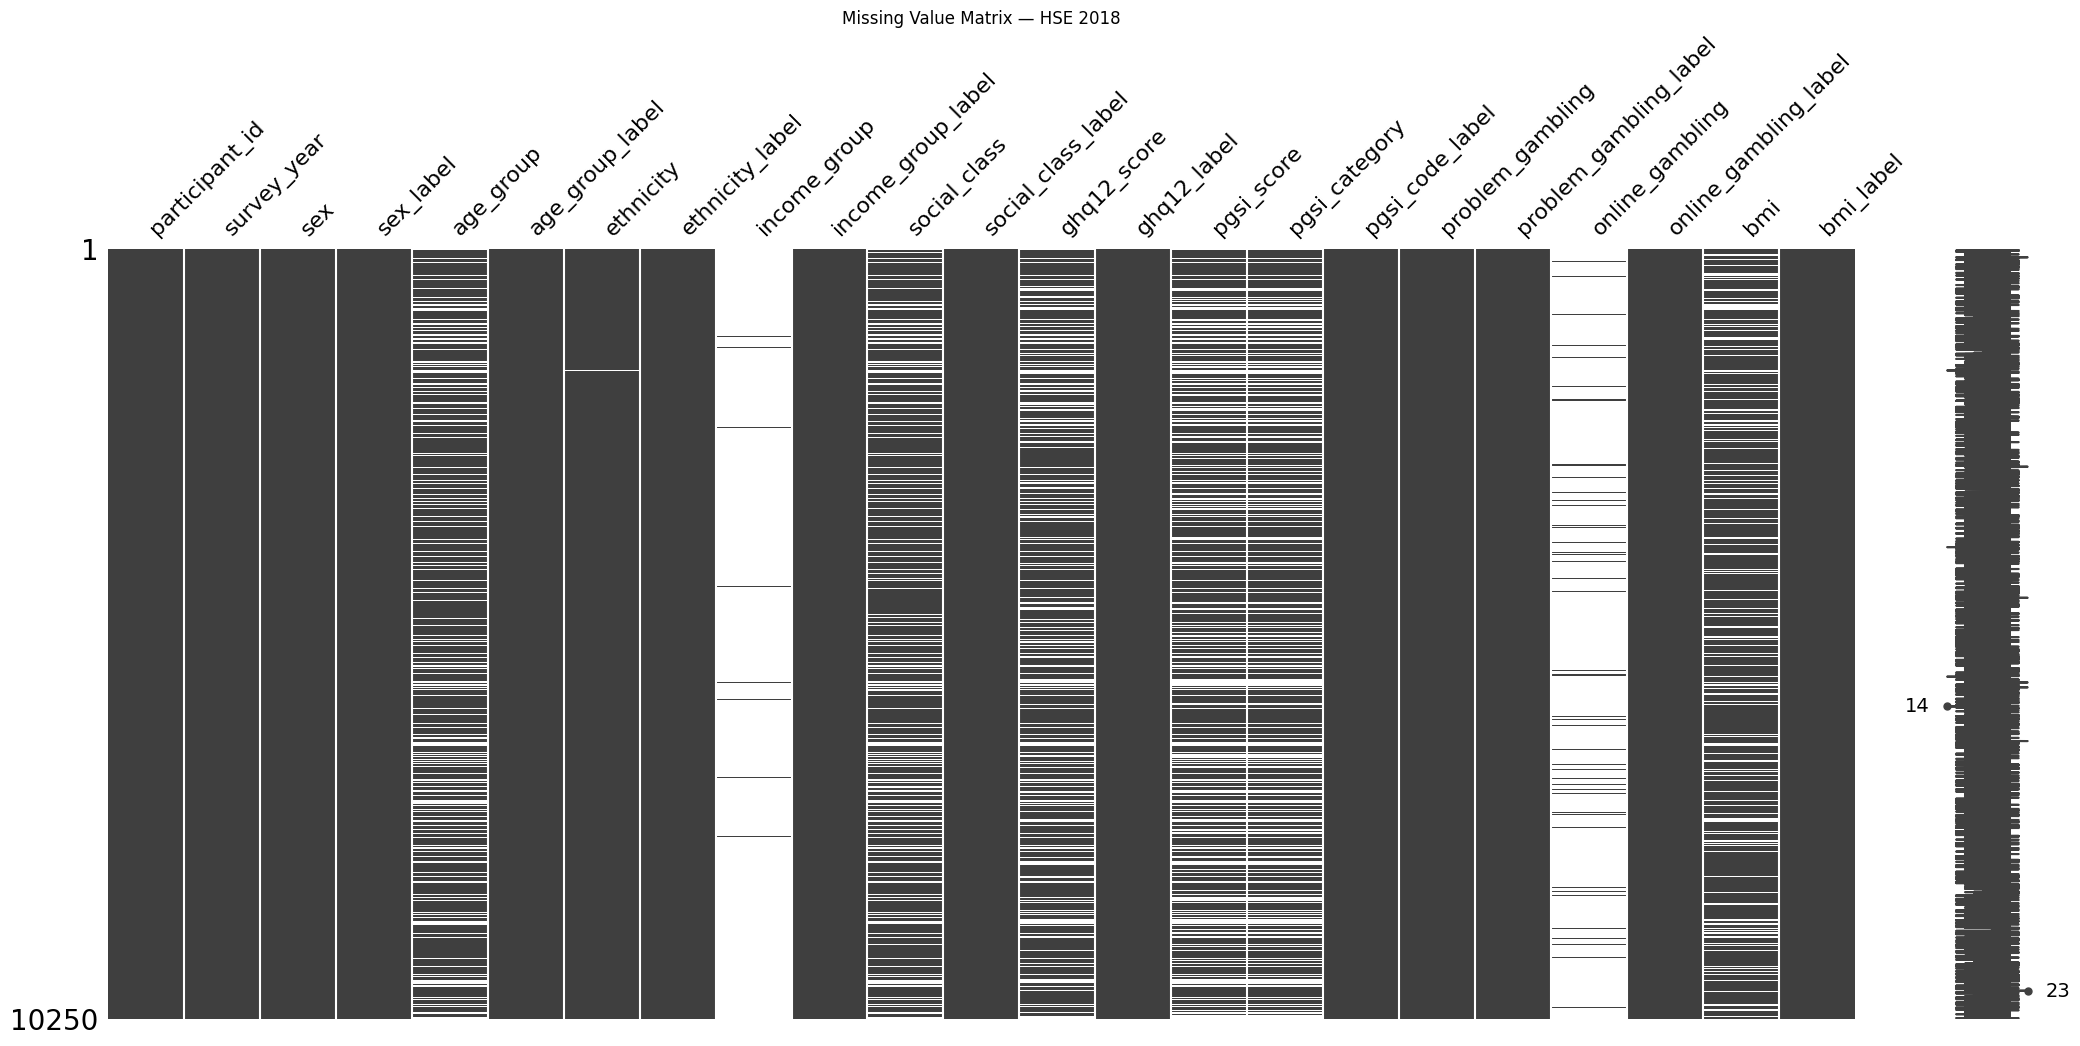

In [18]:

plt.figure(figsize=(18, 10))
msno.matrix(df)
plt.title("Missing Value Matrix — HSE 2018")
plt.show()



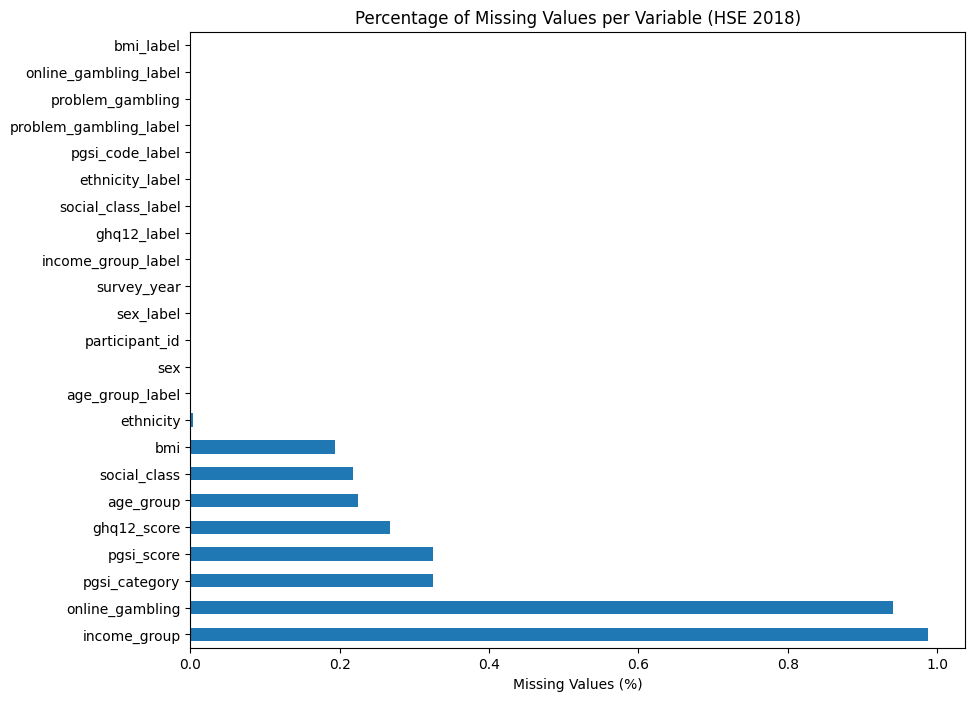

In [19]:
missing = df.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(10,8))
missing.plot(kind="barh")
plt.title("Percentage of Missing Values per Variable (HSE 2018)")
plt.xlabel("Missing Values (%)")
plt.show()



In [20]:
# check for duplicates 
# === Simple Duplicate Check ===
dupe_count = df.duplicated().sum()
print(f"Total duplicate rows: {dupe_count}")

dupe_id_count = df.duplicated(subset=["participant_id"]).sum()
print(f"Duplicate participant_id entries: {dupe_id_count}")


Total duplicate rows: 0
Duplicate participant_id entries: 0


In [21]:
# ------------------------------------------------------------
# D5. Outlier checks for key continuous variables (MAD method)
# ------------------------------------------------------------
# This step is used to identify extreme values for inspection.
# No observations are removed or altered at this stage.

import numpy as np

continuous_vars = ["ghq12_score", "pgsi_score"]

available_vars = [c for c in continuous_vars if c in df.columns]
missing_vars = [c for c in continuous_vars if c not in df.columns]

if missing_vars:
    print(f"Note: the following variables are not available and were skipped: {missing_vars}")

def mad_outliers(series):
    """
    Identify outliers using the Median Absolute Deviation (MAD).
    Returns values classified as extreme; does not modify the data.
    """
    series = series.dropna()
    if len(series) == 0:
        return pd.Series([], dtype=float)

    median = series.median()
    mad = np.median(np.abs(series - median))
    if mad == 0:
        return pd.Series([], dtype=float)

    modified_z = 0.6745 * (series - median) / mad
    return series[np.abs(modified_z) > 3]

for col in available_vars:
    outliers = mad_outliers(df[col])
    print(f"{col}: {len(outliers)} potential outliers identified")


ghq12_score: 0 potential outliers identified
pgsi_score: 0 potential outliers identified


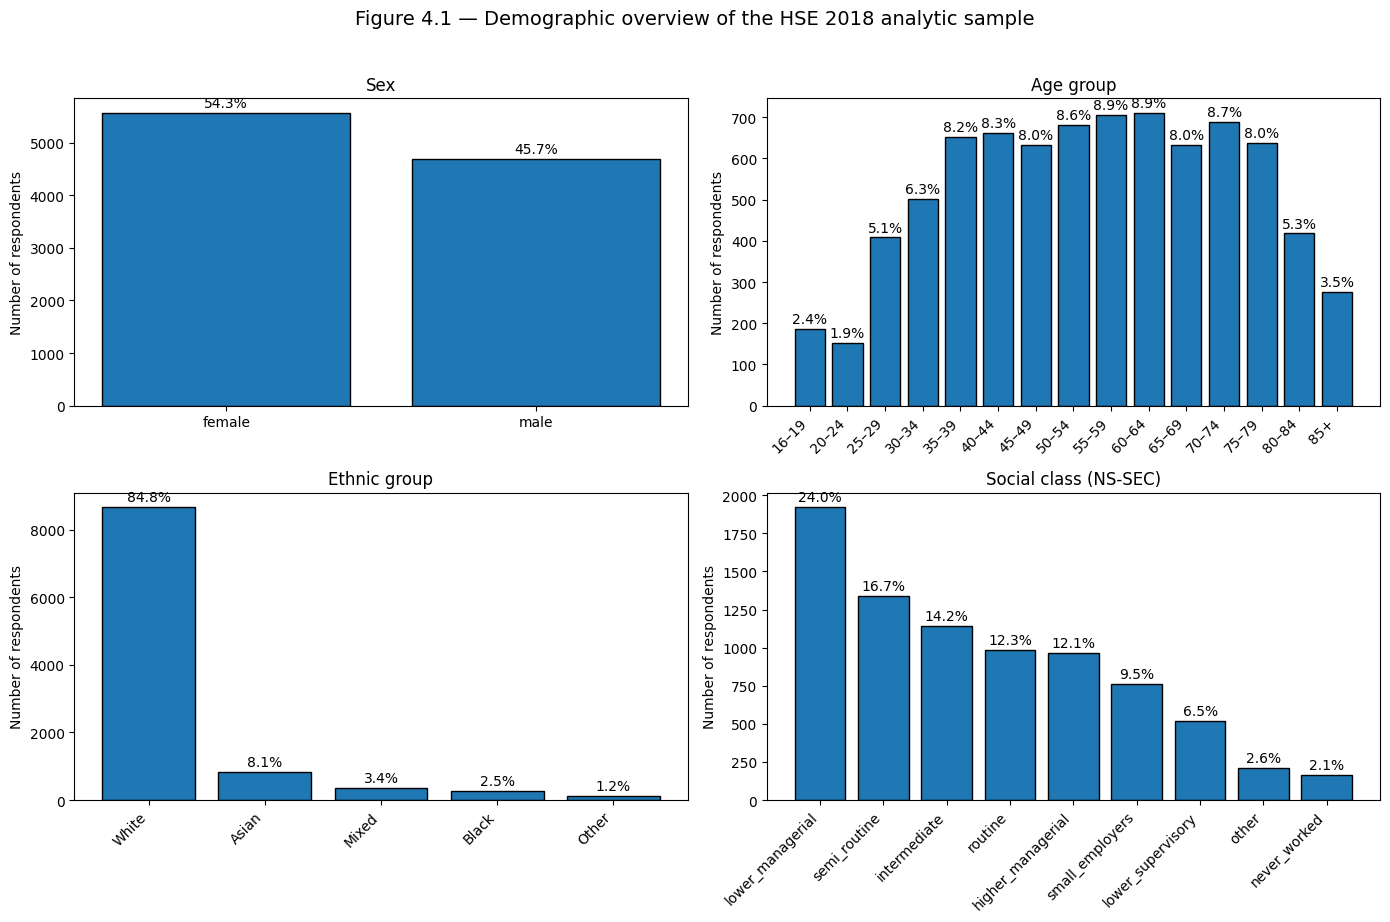

In [22]:
# ======================================================
# FIGURE 4.1 — FOUR-PANEL DEMOGRAPHIC OVERVIEW (HSE 2018)
#   Sex, age group, ethnicity and social class
# ======================================================

import matplotlib.pyplot as plt
import numpy as np

plt.style.use("default")

# ------------------------------------------------------
# Prepare panel layout (2 x 2)
# ------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ------------------------------------------------------
# PANEL A — SEX
# ------------------------------------------------------
sex_counts = df["sex"].value_counts(dropna=False)
sex_perc = sex_counts / sex_counts.sum() * 100

axes[0, 0].bar(sex_counts.index, sex_counts.values,
               edgecolor="black")
axes[0, 0].set_title("Sex")
axes[0, 0].set_ylabel("Number of respondents")
axes[0, 0].set_xlabel("")

for i, v in enumerate(sex_counts):
    axes[0, 0].text(
        i, v + sex_counts.max() * 0.02,
        f"{sex_perc.iloc[i]:.1f}%",
        ha="center"
    )

# ------------------------------------------------------
# PANEL B — AGE GROUP
# ------------------------------------------------------
# ------------------------------------------------------
# PANEL B — AGE GROUP
# ------------------------------------------------------
age_counts = df["age_group"].value_counts(dropna=True).sort_index()
age_perc = age_counts / age_counts.sum() * 100

axes[0, 1].bar(age_counts.index, age_counts.values,
               edgecolor="black")
axes[0, 1].set_title("Age group")
axes[0, 1].set_ylabel("Number of respondents")
axes[0, 1].set_xlabel("")
axes[0, 1].tick_params(axis="x", rotation=45)
plt.setp(axes[0, 1].get_xticklabels(), ha="right")

for i, v in enumerate(age_counts):
    axes[0, 1].text(
        i, v + age_counts.max() * 0.02,
        f"{age_perc.iloc[i]:.1f}%",
        ha="center"
    )
# ------------------------------------------------------
# PANEL C — ETHNIC GROUP
# ------------------------------------------------------
eth_counts = df["ethnicity"].value_counts(dropna=True)
eth_perc = eth_counts / eth_counts.sum() * 100

axes[1, 0].bar(eth_counts.index, eth_counts.values,
               edgecolor="black")
axes[1, 0].set_title("Ethnic group")
axes[1, 0].set_ylabel("Number of respondents")
axes[1, 0].set_xlabel("")
axes[1, 0].tick_params(axis="x", rotation=45)
plt.setp(axes[1, 0].get_xticklabels(), ha="right")

for i, v in enumerate(eth_counts):
    axes[1, 0].text(
        i, v + eth_counts.max() * 0.02,
        f"{eth_perc.iloc[i]:.1f}%",
        ha="center"
    )

# ------------------------------------------------------
# PANEL D — SOCIAL CLASS (NS-SEC)
# ------------------------------------------------------
soc_counts = df["social_class"].value_counts(dropna=True)
soc_perc = soc_counts / soc_counts.sum() * 100

axes[1, 1].bar(soc_counts.index, soc_counts.values,
               edgecolor="black")
axes[1, 1].set_title("Social class (NS-SEC)")
axes[1, 1].set_ylabel("Number of respondents")
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis="x", rotation=45)
plt.setp(axes[1, 1].get_xticklabels(), ha="right")

for i, v in enumerate(soc_counts):
    axes[1, 1].text(
        i, v + soc_counts.max() * 0.02,
        f"{soc_perc.iloc[i]:.1f}%",
        ha="center"
    )

# ------------------------------------------------------
plt.suptitle(
    "Figure 4.1 — Demographic overview of the HSE 2018 analytic sample",
    fontsize=14, y=1.02
)
plt.tight_layout()

# Uncomment to save for thesis submission
# plt.savefig("figure_4_1_hse_demographics.png", dpi=300, bbox_inches="tight")

plt.show()


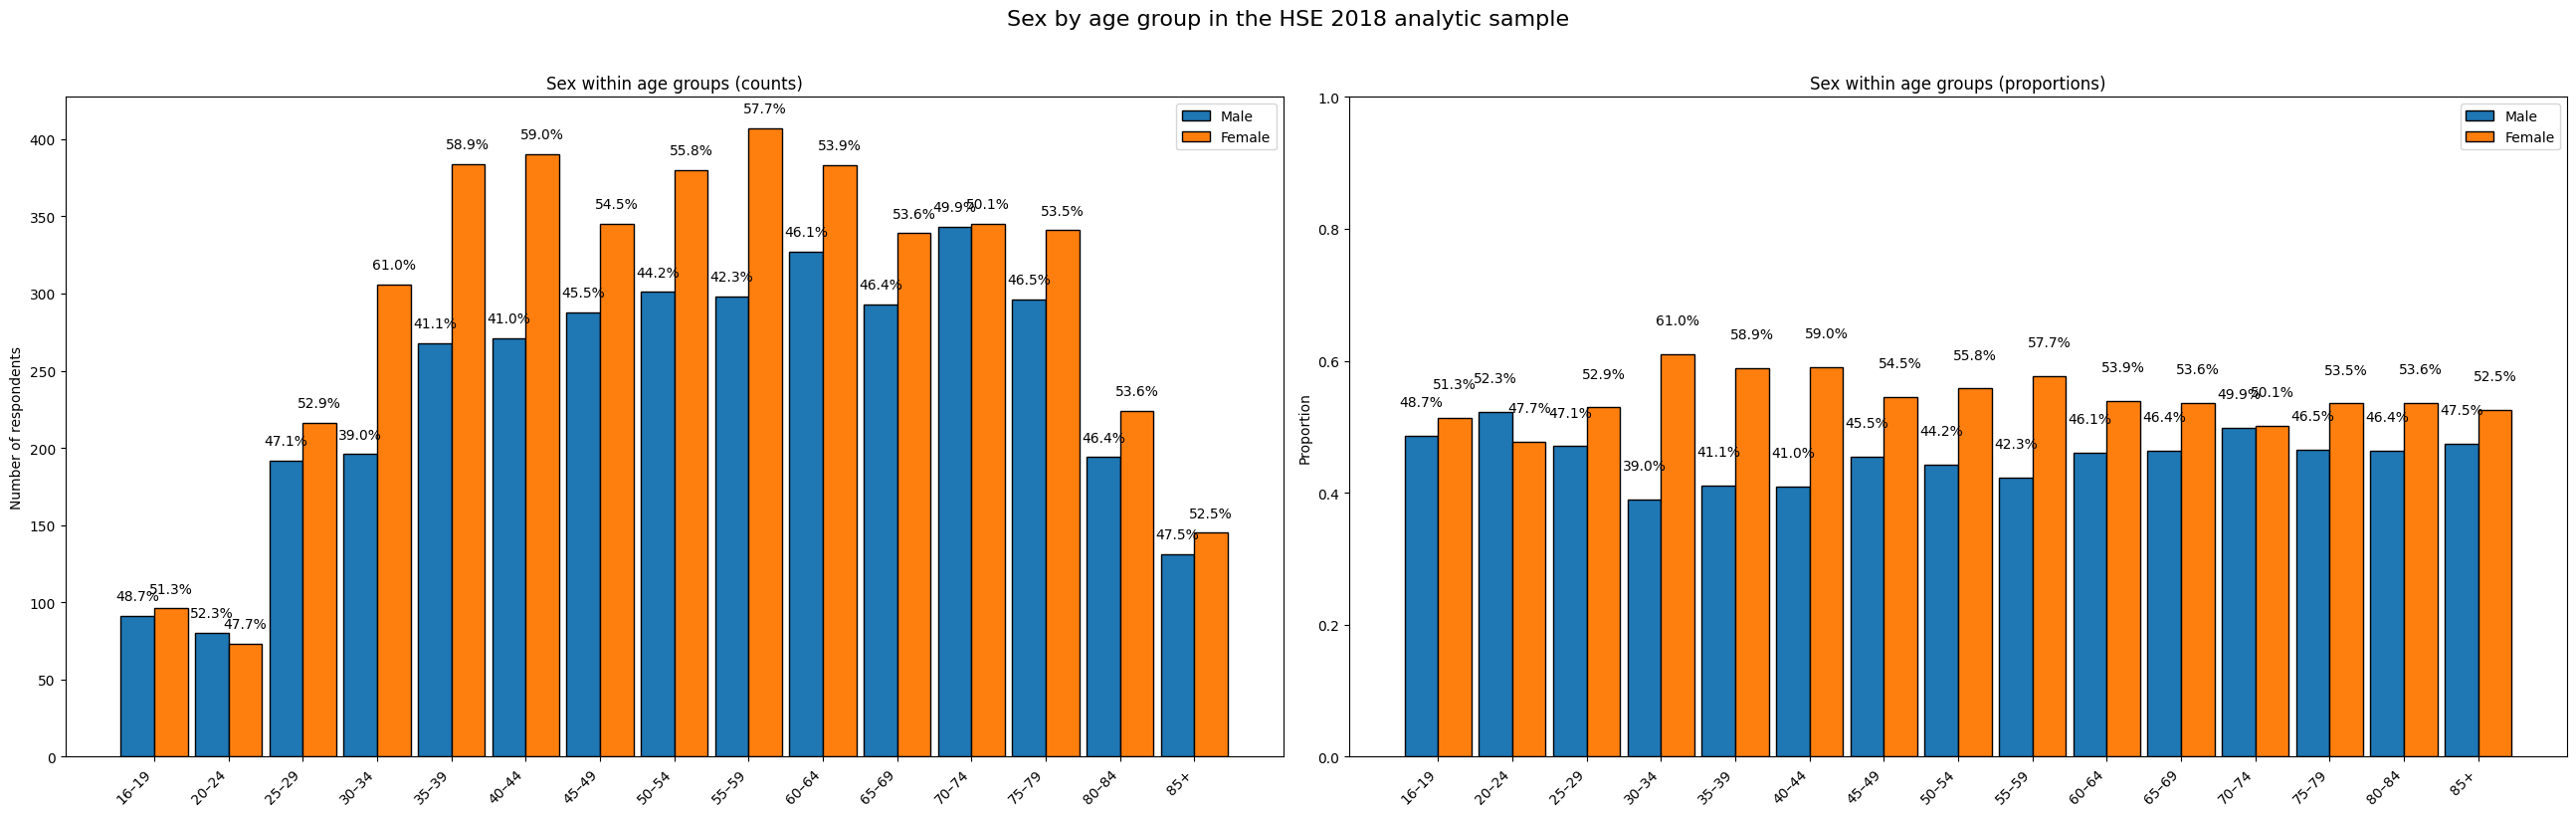

,Age group,Male (n),Male (%),Female (n),Female (%),Total (n)
0,16–19,91,48.7,96,51.3,187
1,20–24,80,52.3,73,47.7,153
2,25–29,192,47.1,216,52.9,408
3,30–34,196,39.0,306,61.0,502
4,35–39,268,41.1,384,58.9,652
5,40–44,271,41.0,390,59.0,661
6,45–49,288,45.5,345,54.5,633
7,50–54,301,44.2,380,55.8,681
8,55–59,298,42.3,407,57.7,705
9,60–64,327,46.1,383,53.9,710


In [23]:
# ======================================================
# Figure — Sex within age groups (counts and proportions)
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Use the same logical ordering already used elsewhere
age_order = [
    "16–19", "20–24", "25–29", "30–34", "35–39",
    "40–44", "45–49", "50–54", "55–59", "60–64",
    "65–69", "70–74", "75–79", "80–84", "85+"
]

# For a figure, exclude missing age_group and missing sex
plot_df = df.loc[df["age_group"].notna() & df["sex"].notna(), ["age_group", "sex"]].copy()

# Ensure age_group follows the logical order
plot_df["age_group"] = pd.Categorical(
    plot_df["age_group"],
    categories=age_order,
    ordered=True
)

# Cross-tab counts and ensure both sex columns exist
xtab_counts = pd.crosstab(plot_df["age_group"], plot_df["sex"]).sort_index()

for col in ["male", "female"]:
    if col not in xtab_counts.columns:
        xtab_counts[col] = 0

xtab_counts = xtab_counts[["male", "female"]]

# Proportions within age group
xtab_prop = xtab_counts.div(xtab_counts.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(26, 8))
x = np.arange(len(xtab_counts.index))
bar_width = 0.45

# ------------------------------------------------------
# LEFT PANEL — COUNTS (+ % labels)
# ------------------------------------------------------
axes[0].bar(
    x - bar_width/2,
    xtab_counts["male"].values,
    width=bar_width,
    edgecolor="black",
    label="Male"
)
axes[0].bar(
    x + bar_width/2,
    xtab_counts["female"].values,
    width=bar_width,
    edgecolor="black",
    label="Female"
)

axes[0].set_title("Sex within age groups (counts)")
axes[0].set_ylabel("Number of respondents")
axes[0].set_xticks(x)
axes[0].set_xticklabels(xtab_counts.index.astype(str), rotation=45, ha="right")
axes[0].legend()

y_pad = xtab_counts.values.max() * 0.025

for i, age in enumerate(xtab_counts.index):
    male_n = xtab_counts.loc[age, "male"]
    female_n = xtab_counts.loc[age, "female"]

    male_pct = xtab_prop.loc[age, "male"] * 100 if xtab_counts.loc[age].sum() > 0 else 0
    female_pct = xtab_prop.loc[age, "female"] * 100 if xtab_counts.loc[age].sum() > 0 else 0

    axes[0].text(x[i] - bar_width/2, male_n + y_pad, f"{male_pct:.1f}%", ha="center")
    axes[0].text(x[i] + bar_width/2, female_n + y_pad, f"{female_pct:.1f}%", ha="center")

# ------------------------------------------------------
# RIGHT PANEL — PROPORTIONS (+ % labels)
# ------------------------------------------------------
axes[1].bar(
    x - bar_width/2,
    xtab_prop["male"].values,
    width=bar_width,
    edgecolor="black",
    label="Male"
)
axes[1].bar(
    x + bar_width/2,
    xtab_prop["female"].values,
    width=bar_width,
    edgecolor="black",
    label="Female"
)

axes[1].set_title("Sex within age groups (proportions)")
axes[1].set_ylabel("Proportion")
axes[1].set_xticks(x)
axes[1].set_xticklabels(xtab_counts.index.astype(str), rotation=45, ha="right")
axes[1].set_ylim(0, 1)
axes[1].legend()

for i, age in enumerate(xtab_prop.index):
    male_p = xtab_prop.loc[age, "male"]
    female_p = xtab_prop.loc[age, "female"]

    axes[1].text(x[i] - bar_width/2, male_p + 0.045, f"{male_p*100:.1f}%", ha="center")
    axes[1].text(x[i] + bar_width/2, female_p + 0.045, f"{female_p*100:.1f}%", ha="center")

plt.suptitle("Sex by age group in the HSE 2018 analytic sample", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
# ------------------------------------------------------
# Table — Sex by age group (counts and row percentages)
# ------------------------------------------------------

# Start from the same plotting dataframe for consistency
tab_df = plot_df.copy()

# Build count table
table_sex_age = (
    tab_df
    .groupby(["age_group", "sex"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(age_order)
)

# Ensure both columns exist
for col in ["male", "female"]:
    if col not in table_sex_age.columns:
        table_sex_age[col] = 0

table_sex_age = table_sex_age[["male", "female"]]

# Row totals
table_sex_age["Total"] = table_sex_age.sum(axis=1)

# Row percentages
table_sex_age_pct = (
    table_sex_age[["male", "female"]]
    .div(table_sex_age["Total"], axis=0)
    .mul(100)
    .round(1)
)

# Combine counts and percentages into a single tidy table
table_4_sex_age = pd.DataFrame({
    "Age group": table_sex_age.index,
    "Male (n)": table_sex_age["male"].values,
    "Male (%)": table_sex_age_pct["male"].values,
    "Female (n)": table_sex_age["female"].values,
    "Female (%)": table_sex_age_pct["female"].values,
    "Total (n)": table_sex_age["Total"].values
})

display(table_4_sex_age)

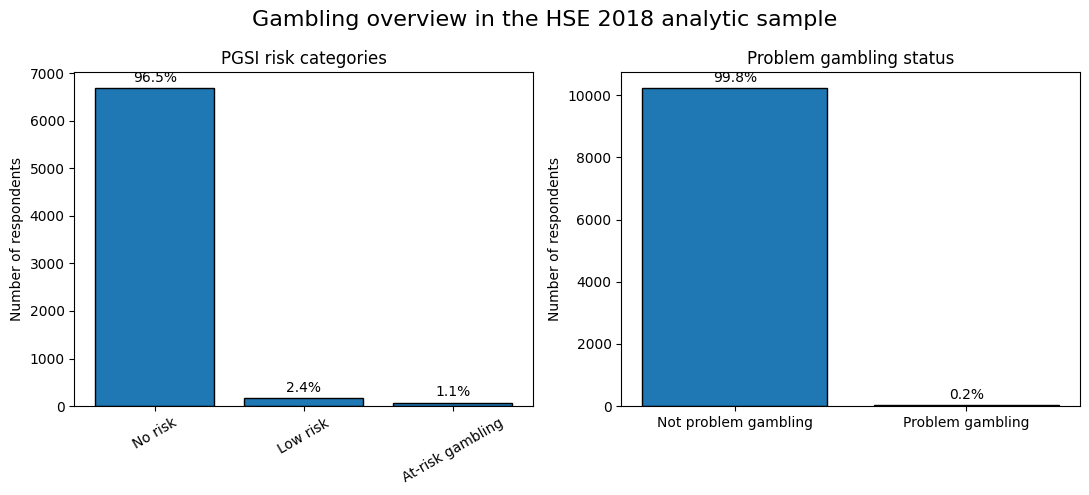

In [ ]:
# ======================================================
# Figure — Gambling Overview (HSE 2018)
#   PGSI (3 categories) and problem gambling
# ======================================================
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")

# ---------------------------------------------
# Ensure PGSI 3-category exists
# ---------------------------------------------
df["pgsi_3cat"] = pd.cut(
    df["pgsi_score"],
    bins=[-0.1, 0, 2, 27],
    labels=["No risk", "Low risk", "At-risk gambling"]
)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# ------------------------------------------------------
# PANEL A — PGSI (3-category)
# ------------------------------------------------------
pgsi_counts = df["pgsi_3cat"].value_counts().reindex(
    ["No risk", "Low risk", "At-risk gambling"]
)
pgsi_perc = pgsi_counts / pgsi_counts.sum() * 100

axes[0].bar(pgsi_counts.index, pgsi_counts.values, edgecolor="black")
axes[0].set_title("PGSI risk categories")
axes[0].set_ylabel("Number of respondents")
axes[0].tick_params(axis="x", rotation=30)

for i, v in enumerate(pgsi_counts):
    axes[0].text(
        i, v + pgsi_counts.max() * 0.02,
        f"{pgsi_perc.iloc[i]:.1f}%",
        ha="center"
    )

# ------------------------------------------------------
# PANEL B — Problem gambling (binary)
# ------------------------------------------------------
pg_flag_counts = df["problem_gambling"].value_counts().sort_index()
pg_flag_perc = pg_flag_counts / pg_flag_counts.sum() * 100

axes[1].bar(
    ["Not problem gambling", "Problem gambling"],
    pg_flag_counts.values,
    edgecolor="black"
)
axes[1].set_title("Problem gambling status")
axes[1].set_ylabel("Number of respondents")

for i, v in enumerate(pg_flag_counts):
    axes[1].text(
        i, v + pg_flag_counts.max() * 0.02,
        f"{pg_flag_perc.iloc[i]:.1f}%",
        ha="center"
    )

plt.suptitle(
    "Gambling overview in the HSE 2018 analytic sample",
    fontsize=16
)
plt.tight_layout()
plt.show()


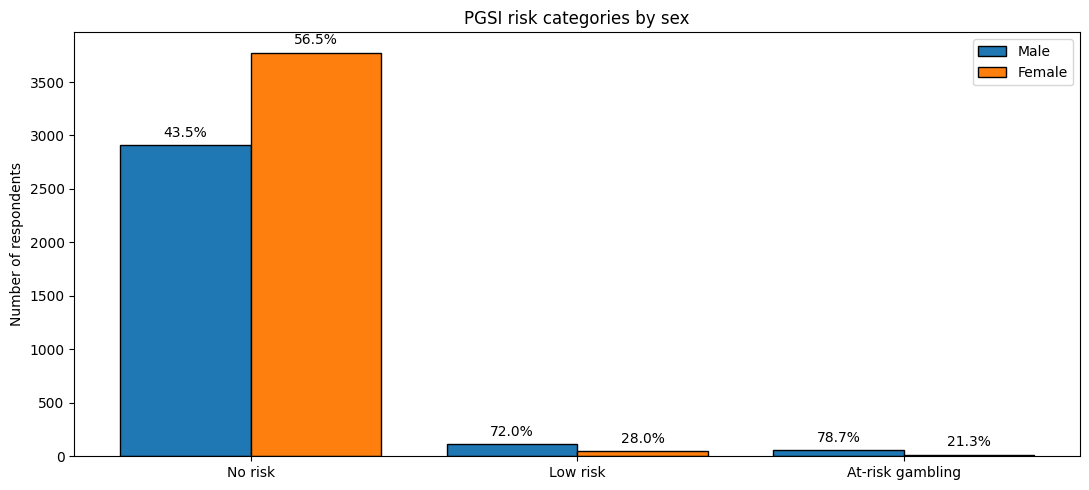

In [34]:
# ======================================================
# Figure 4A — PGSI categories by sex (counts and percentages)
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Restrict to observed PGSI category and sex
plot_df = df.loc[
    df["pgsi_3cat"].notna() & df["sex"].notna(),
    ["pgsi_3cat", "sex"]
].copy()

# Ensure consistent ordering
pgsi_order = ["No risk", "Low risk", "At-risk gambling"]
plot_df["pgsi_3cat"] = pd.Categorical(
    plot_df["pgsi_3cat"],
    categories=pgsi_order,
    ordered=True
)

# Cross-tabulation
xtab_sex = (
    plot_df
    .groupby(["pgsi_3cat", "sex"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(pgsi_order)
)

# Ensure both sex columns exist
for col in ["male", "female"]:
    if col not in xtab_sex.columns:
        xtab_sex[col] = 0

xtab_sex = xtab_sex[["male", "female"]]

# Row proportions
xtab_sex_prop = xtab_sex.div(xtab_sex.sum(axis=1), axis=0)

# ------------------------------------------------------
# Plot
# ------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(pgsi_order))
bar_width = 0.4

ax.bar(
    x - bar_width/2,
    xtab_sex["male"].values,
    width=bar_width,
    edgecolor="black",
    label="Male"
)
ax.bar(
    x + bar_width/2,
    xtab_sex["female"].values,
    width=bar_width,
    edgecolor="black",
    label="Female"
)

ax.set_title("PGSI risk categories by sex")
ax.set_ylabel("Number of respondents")
ax.set_xticks(x)
ax.set_xticklabels(pgsi_order)
ax.legend()

# Percentage labels
y_pad = xtab_sex.values.max() * 0.02

for i, cat in enumerate(pgsi_order):
    male_pct = xtab_sex_prop.loc[cat, "male"] * 100
    female_pct = xtab_sex_prop.loc[cat, "female"] * 100

    ax.text(
        x[i] - bar_width/2,
        xtab_sex.loc[cat, "male"] + y_pad,
        f"{male_pct:.1f}%",
        ha="center"
    )
    ax.text(
        x[i] + bar_width/2,
        xtab_sex.loc[cat, "female"] + y_pad,
        f"{female_pct:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


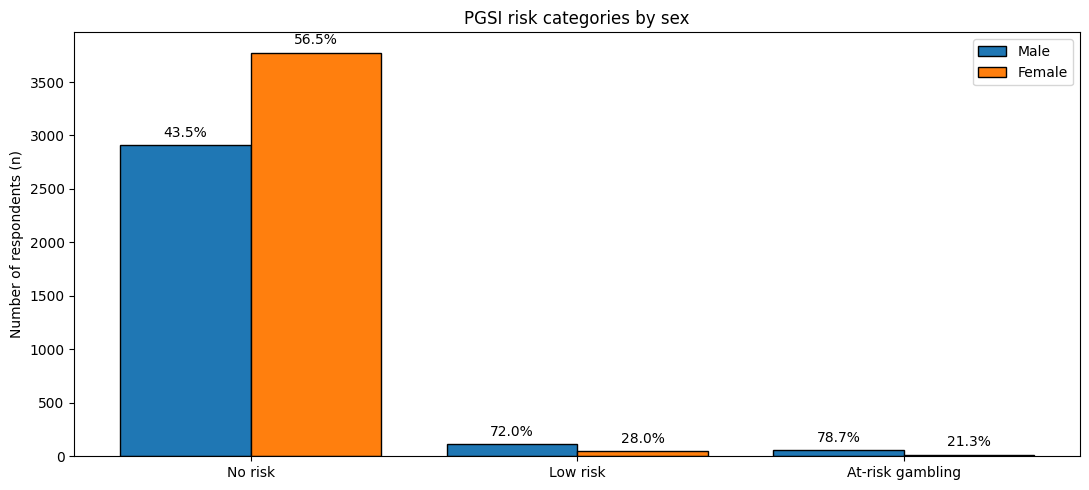

In [35]:
# ======================================================
# Figure 4A — PGSI categories by sex (counts and percentages)
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Restrict to observed PGSI category and sex
plot_df = df.loc[
    df["pgsi_3cat"].notna() & df["sex"].notna(),
    ["pgsi_3cat", "sex"]
].copy()

# Ensure consistent ordering
pgsi_order = ["No risk", "Low risk", "At-risk gambling"]
plot_df["pgsi_3cat"] = pd.Categorical(
    plot_df["pgsi_3cat"],
    categories=pgsi_order,
    ordered=True
)

# Cross-tabulation
xtab_sex = (
    plot_df
    .groupby(["pgsi_3cat", "sex"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(pgsi_order)
)

# Ensure both sex columns exist
for col in ["male", "female"]:
    if col not in xtab_sex.columns:
        xtab_sex[col] = 0

xtab_sex = xtab_sex[["male", "female"]]

# Row proportions
xtab_sex_prop = xtab_sex.div(xtab_sex.sum(axis=1), axis=0)

# ------------------------------------------------------
# Plot
# ------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(pgsi_order))
bar_width = 0.4

ax.bar(
    x - bar_width/2,
    xtab_sex["male"].values,
    width=bar_width,
    edgecolor="black",
    label="Male"
)
ax.bar(
    x + bar_width/2,
    xtab_sex["female"].values,
    width=bar_width,
    edgecolor="black",
    label="Female"
)

ax.set_title("PGSI risk categories by sex")
ax.set_ylabel("Number of respondents (n)") 
ax.set_xticks(x)
ax.set_xticklabels(pgsi_order)
ax.legend()

# Percentage labels
y_pad = xtab_sex.values.max() * 0.02

for i, cat in enumerate(pgsi_order):
    male_pct = xtab_sex_prop.loc[cat, "male"] * 100
    female_pct = xtab_sex_prop.loc[cat, "female"] * 100

    ax.text(
        x[i] - bar_width/2,
        xtab_sex.loc[cat, "male"] + y_pad,
        f"{male_pct:.1f}%",
        ha="center"
    )
    ax.text(
        x[i] + bar_width/2,
        xtab_sex.loc[cat, "female"] + y_pad,
        f"{female_pct:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


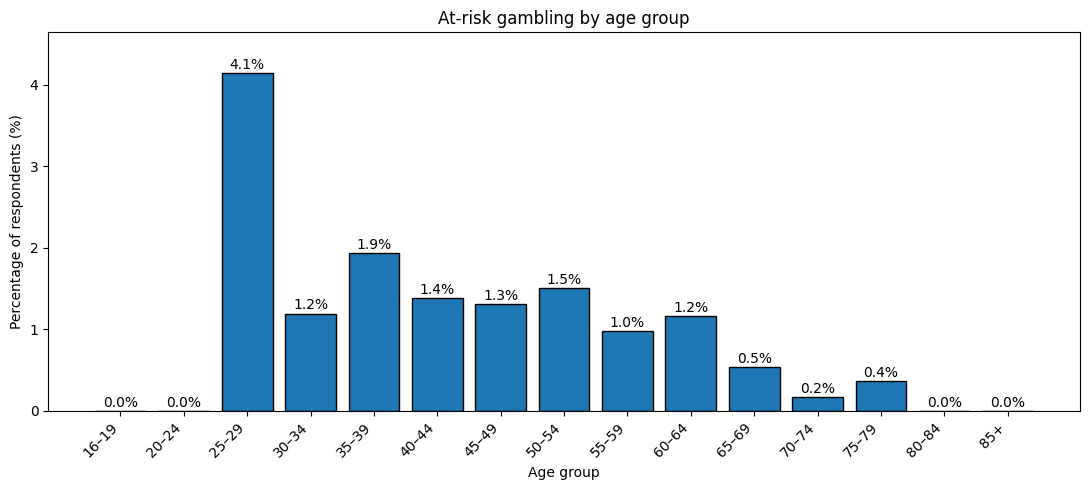

In [36]:
# ======================================================
# Figure 4B — At-risk gambling by age group (HSE 2018)
# ======================================================

import matplotlib.pyplot as plt
import pandas as pd

# Restrict to observed age group and PGSI category
plot_df = df.loc[
    df["age_group"].notna() & df["pgsi_3cat"].notna(),
    ["age_group", "pgsi_3cat"]
].copy()

# Ensure correct age ordering (reuse agreed structure)
age_order = [
    "16–19", "20–24", "25–29", "30–34", "35–39",
    "40–44", "45–49", "50–54", "55–59", "60–64",
    "65–69", "70–74", "75–79", "80–84", "85+"
]

plot_df["age_group"] = pd.Categorical(
    plot_df["age_group"],
    categories=age_order,
    ordered=True
)

# Calculate percentage at-risk within each age group
age_pgsi = (
    plot_df
    .groupby(["age_group", "pgsi_3cat"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(age_order)
)

age_pgsi_pct = age_pgsi.div(age_pgsi.sum(axis=1), axis=0) * 100

# Focus on at-risk gambling only
at_risk_pct = age_pgsi_pct["At-risk gambling"]

# ------------------------------------------------------
# Plot
# ------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(at_risk_pct.index, at_risk_pct.values, edgecolor="black")

ax.set_title("At-risk gambling by age group")
ax.set_ylabel("Percentage of respondents (%)")
ax.set_xlabel("Age group")
ax.set_ylim(0, at_risk_pct.max() + 0.5)
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right")

# Percentage labels
for i, v in enumerate(at_risk_pct):
    ax.text(i, v + 0.05, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()


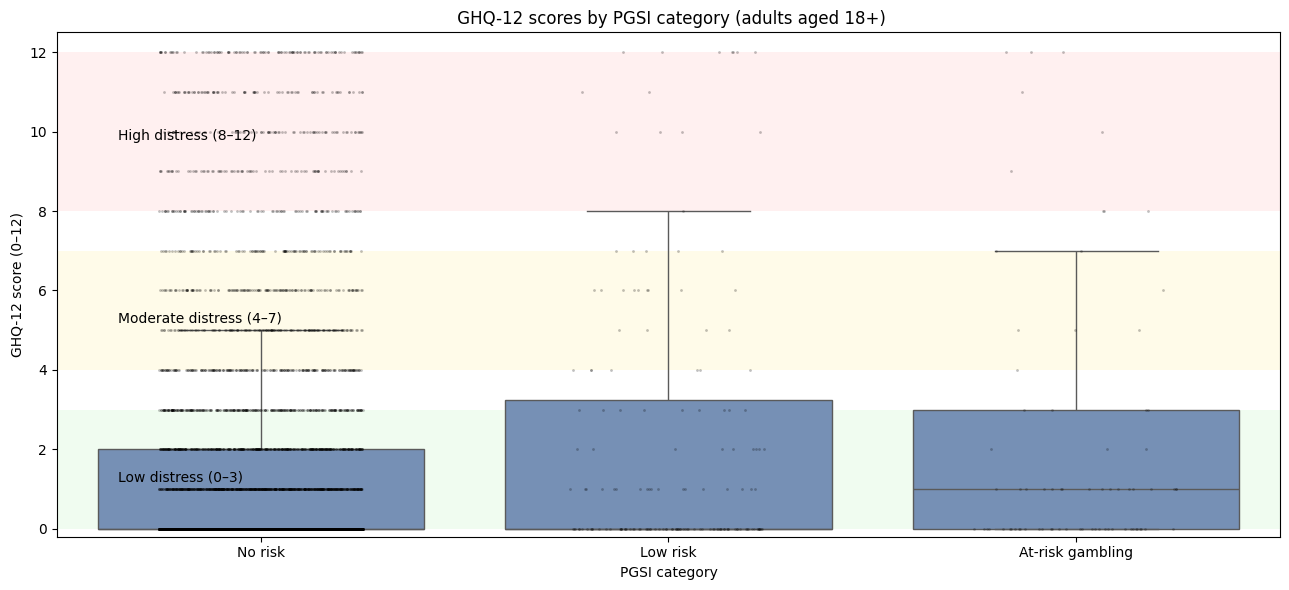

In [38]:
# ======================================================
# Figure 5 — GHQ-12 by PGSI (3 categories, adults only)
# ======================================================

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("default")

# ------------------------------------------------------
# Restrict to adults (18+)
# ------------------------------------------------------
df_adult = df[df["age_group"] != "16–19"].copy()

# Ensure numeric GHQ-12
df_adult["ghq12_score"] = pd.to_numeric(df_adult["ghq12_score"], errors="coerce")

# PGSI order (3-category)
pgsi_order = ["No risk", "Low risk", "At-risk gambling"]

plt.figure(figsize=(13, 6))

# ------------------------------------------------------
# Shaded GHQ-12 interpretation bands (descriptive)
# ------------------------------------------------------
plt.axhspan(0, 3, facecolor="#d4f7d4", alpha=0.35)
plt.axhspan(4, 7, facecolor="#fff4c2", alpha=0.35)
plt.axhspan(8, 12, facecolor="#ffd6d6", alpha=0.35)

# ------------------------------------------------------
# Boxplot
# ------------------------------------------------------
sns.boxplot(
    data=df_adult,
    x="pgsi_3cat",
    y="ghq12_score",
    order=pgsi_order,
    color="#6c8ebf",
    showfliers=False
)

# ------------------------------------------------------
# Jittered points (light, non-dominant)
# ------------------------------------------------------
sns.stripplot(
    data=df_adult,
    x="pgsi_3cat",
    y="ghq12_score",
    order=pgsi_order,
    color="black",
    size=2,
    alpha=0.25,
    jitter=0.25
)

# ------------------------------------------------------
# Labels
# ------------------------------------------------------
plt.text(-0.35, 1.2, "Low distress (0–3)", fontsize=10)
plt.text(-0.35, 5.2, "Moderate distress (4–7)", fontsize=10)
plt.text(-0.35, 9.8, "High distress (8–12)", fontsize=10)

plt.title(" GHQ-12 scores by PGSI category (adults aged 18+)")
plt.xlabel("PGSI category")
plt.ylabel("GHQ-12 score (0–12)")
plt.ylim(-0.2, 12.5)

plt.tight_layout()
plt.show()


In [ ]:
# ======================================================
# Create GHQ-12 psychological distress indicator (0–3 vs 4+)
# ======================================================

# Ensure numeric GHQ-12
df["ghq12_score"] = pd.to_numeric(df["ghq12_score"], errors="coerce")

# Binary distress indicator using standard threshold
df["ghq12_distress"] = pd.cut(
    df["ghq12_score"],
    bins=[-0.1, 3, 12],
    labels=["low_distress", "high_distress"]
)

# Check distribution
print(df["ghq12_distress"].value_counts(dropna=False))


ghq12_distress
low_distress     6284
NaN              2747
high_distress    1219
Name: count, dtype: int64


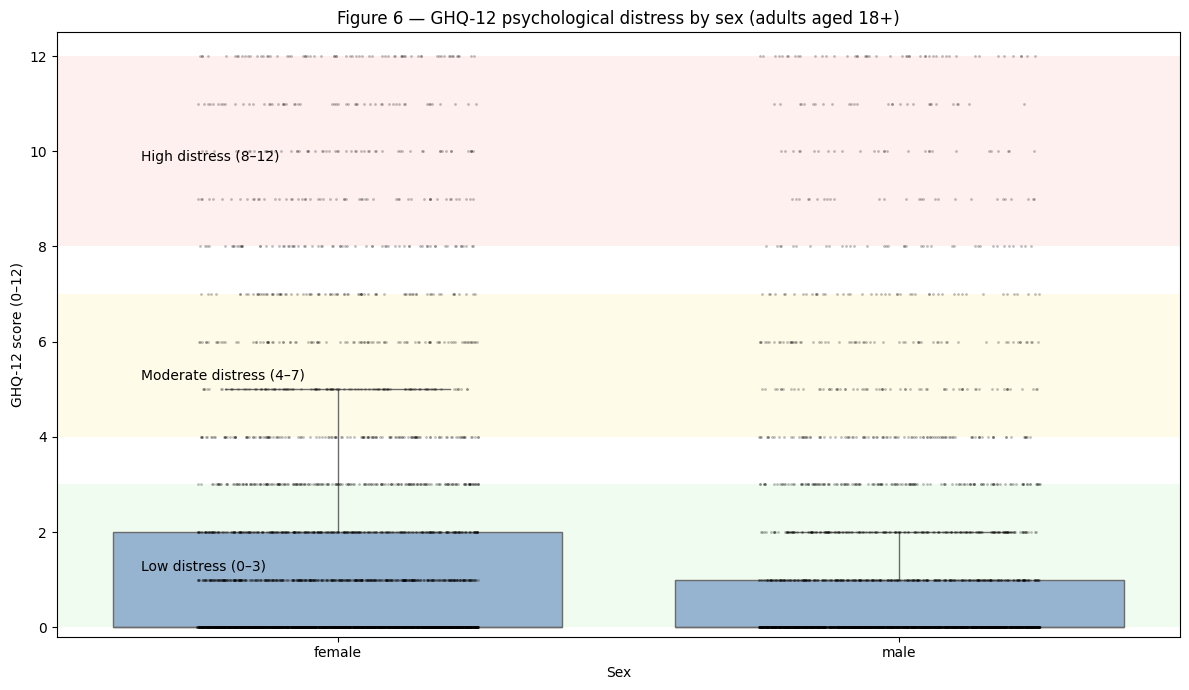

In [39]:
# ======================================================
# Figure 6 — GHQ-12 Psychological Distress by Sex (Adults 18+)
# ======================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use("default")

# ------------------------------------------------------
# Adults only (18+)
# ------------------------------------------------------
df_adult = df[df["age_group"] != "16–19"].copy()

# Ensure GHQ-12 is numeric
df_adult["ghq12_score"] = pd.to_numeric(df_adult["ghq12_score"], errors="coerce")

plt.figure(figsize=(12, 7))

# ------------------------------------------------------
# Shaded GHQ-12 interpretation bands (descriptive only)
# ------------------------------------------------------
plt.axhspan(0, 3, facecolor="#d4f7d4", alpha=0.35)
plt.axhspan(4, 7, facecolor="#fff4c2", alpha=0.35)
plt.axhspan(8, 12, facecolor="#ffd6d6", alpha=0.35)

# ------------------------------------------------------
# Boxplot
# ------------------------------------------------------
sns.boxplot(
    data=df_adult,
    x="sex",
    y="ghq12_score",
    color="#8cb3d9",
    showfliers=False
)

# ------------------------------------------------------
# Jittered points
# ------------------------------------------------------
sns.stripplot(
    data=df_adult,
    x="sex",
    y="ghq12_score",
    color="black",
    size=2,
    alpha=0.25,
    jitter=0.25
)

# ------------------------------------------------------
# Labels
# ------------------------------------------------------
plt.text(-0.35, 1.2, "Low distress (0–3)", fontsize=10)
plt.text(-0.35, 5.2, "Moderate distress (4–7)", fontsize=10)
plt.text(-0.35, 9.8, "High distress (8–12)", fontsize=10)

plt.title("Figure 6 — GHQ-12 psychological distress by sex (adults aged 18+)")
plt.xlabel("Sex")
plt.ylabel("GHQ-12 score (0–12)")
plt.ylim(-0.2, 12.5)

plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_23456\2375418197.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("pgsi_3cat")["ghq12_distress"]


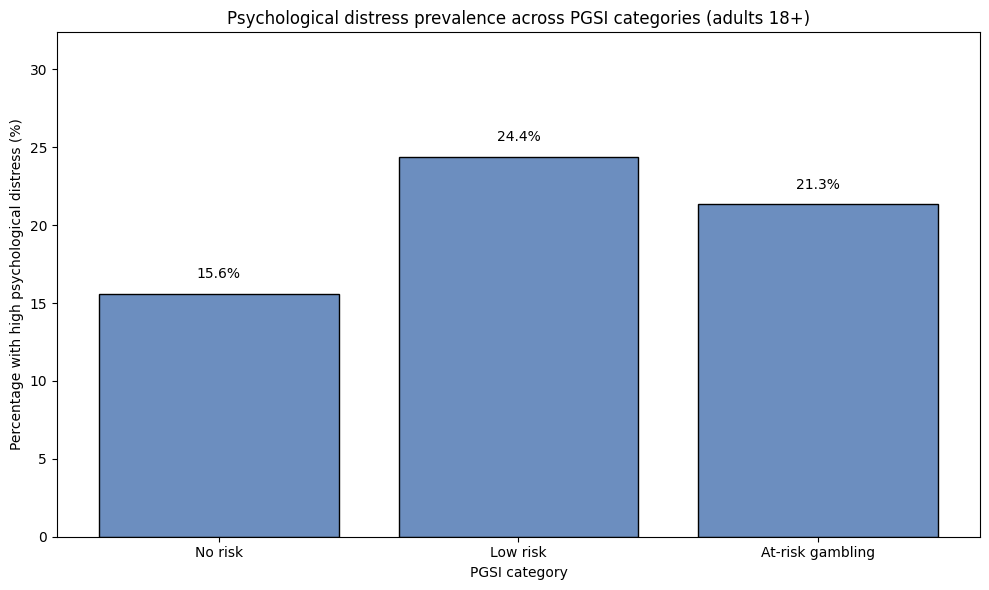

In [ ]:
# ======================================================
# Figure — Psychological distress prevalence by PGSI category
# ======================================================

import matplotlib.pyplot as plt
import numpy as np

# Adults only
df_adult = df[df["age_group"] != "16–19"].copy()

# Ensure correct types
df_adult["ghq12_distress"] = df_adult["ghq12_distress"].astype("category")

pgsi_order = ["No risk", "Low risk", "At-risk gambling"]

# Calculate prevalence (% distressed)
distress_rate = (
    df_adult
    .groupby("pgsi_3cat")["ghq12_distress"]
    .apply(lambda x: (x == "high_distress").mean() * 100)
    .reindex(pgsi_order)
)

plt.figure(figsize=(10, 6))

plt.bar(
    distress_rate.index,
    distress_rate.values,
    edgecolor="black",
    color="#6c8ebf"
)

plt.ylabel("Percentage with high psychological distress (%)")
plt.xlabel("PGSI category")
plt.title("Psychological distress prevalence across PGSI categories (adults 18+)")

# % labels
for i, v in enumerate(distress_rate):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.ylim(0, distress_rate.max() + 8)
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_23456\3096348574.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("age_group")["ghq12_distress"]


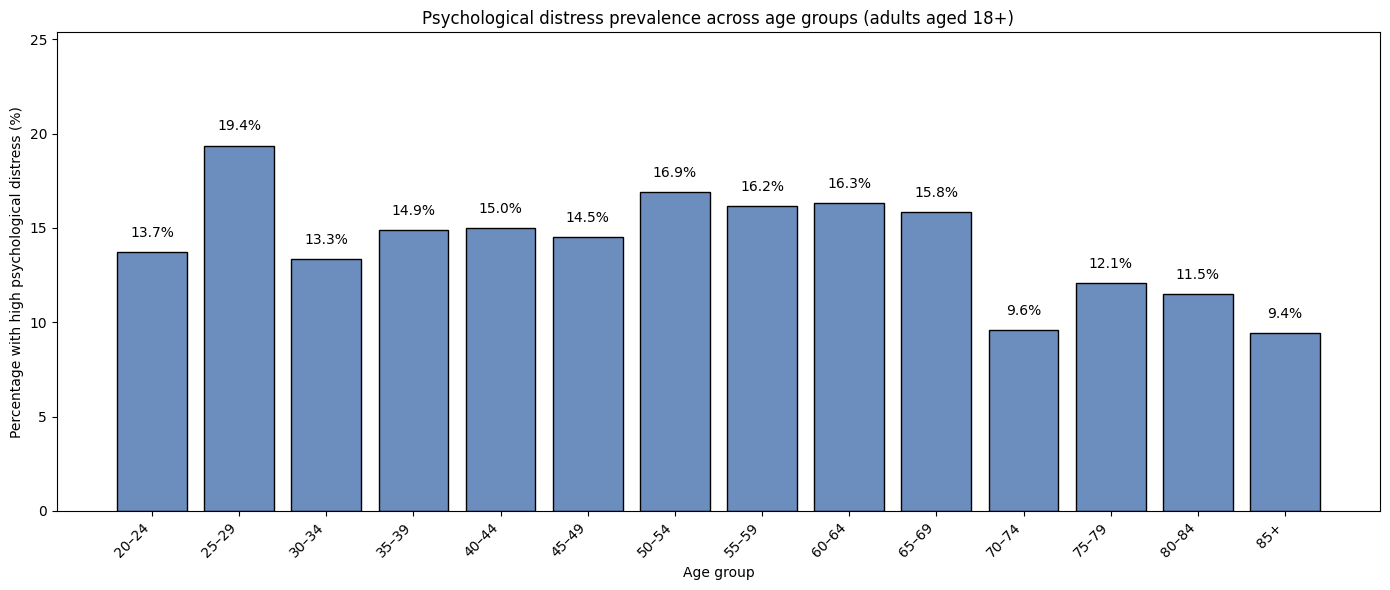

In [ ]:
# ======================================================
# Figure — Psychological distress prevalence by age group (adults 18+)
# ======================================================

import matplotlib.pyplot as plt
import numpy as np

# Adults only
df_adult = df[df["age_group"] != "16–19"].copy()

# Ensure distress variable exists
df_adult["ghq12_distress"] = df_adult["ghq12_distress"].astype("category")

# Order age groups
age_order = sorted(
    [g for g in df_adult["age_group"].dropna().unique()],
    key=lambda x: int(x.split("–")[0].replace("+", ""))
)

# Calculate prevalence (% high distress)
distress_by_age = (
    df_adult
    .groupby("age_group")["ghq12_distress"]
    .apply(lambda x: (x == "high_distress").mean() * 100)
    .reindex(age_order)
)

plt.figure(figsize=(14, 6))

plt.bar(
    distress_by_age.index,
    distress_by_age.values,
    color="#6c8ebf",
    edgecolor="black"
)

plt.ylabel("Percentage with high psychological distress (%)")
plt.xlabel("Age group")
plt.title("Psychological distress prevalence across age groups (adults aged 18+)")
plt.xticks(rotation=45, ha="right")

# % labels
for i, v in enumerate(distress_by_age):
    plt.text(i, v + 0.8, f"{v:.1f}%", ha="center")

plt.ylim(0, distress_by_age.max() + 6)
plt.tight_layout()
plt.show()


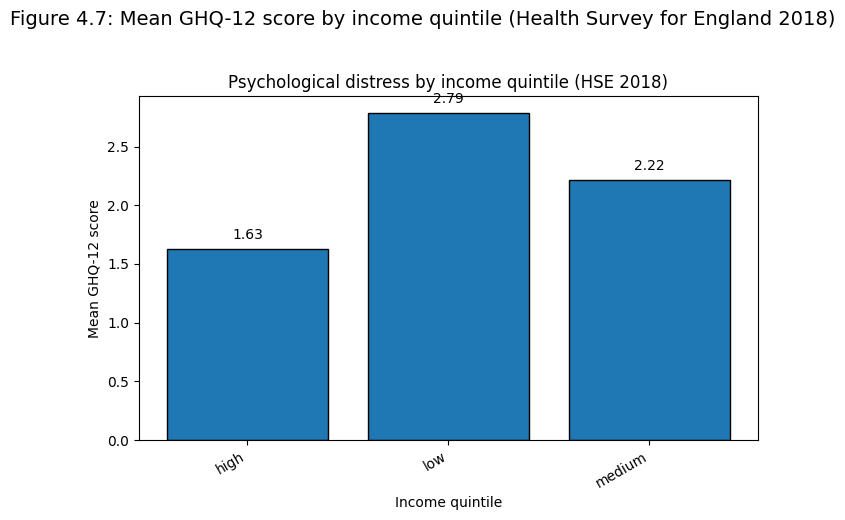

In [47]:
import matplotlib.pyplot as plt

plt.style.use("default")

# ------------------------------------------------------
# Prepare data: GHQ-12 by income group (HSE 2018)
# ------------------------------------------------------
income_summary = (
    df.groupby(["income_group"])["ghq12_score"]
      .agg(mean="mean", n="count")
      .reset_index()
      .sort_values("income_group")
)

# ------------------------------------------------------
# Plot
# ------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    income_summary["income_group"],
    income_summary["mean"],
    edgecolor="black"
)

ax.set_xlabel("Income quintile")
ax.set_ylabel("Mean GHQ-12 score")
ax.set_title("Psychological distress by income quintile (HSE 2018)")

ax.tick_params(axis="x", rotation=30)
plt.setp(ax.get_xticklabels(), ha="right")

# Exact numeric labels
for i, v in enumerate(income_summary["mean"]):
    ax.text(
        i,
        v + income_summary["mean"].max() * 0.03,
        f"{v:.2f}",
        ha="center"
    )

# ------------------------------------------------------
# Figure caption (dissertation-ready)
# ------------------------------------------------------
fig.suptitle(
    "Figure 4.7: Mean GHQ-12 score by income quintile (Health Survey for England 2018)",
    fontsize=14,
    y=1.03
)

plt.tight_layout()
plt.show()


In [44]:
from streamlit import columns


sorted(df.columns.to_list())

['age_group',
 'age_group_label',
 'bmi',
 'bmi_label',
 'ethnicity',
 'ethnicity_label',
 'ghq12_label',
 'ghq12_score',
 'income_group',
 'income_group_label',
 'online_gambling',
 'online_gambling_label',
 'participant_id',
 'pgsi_3cat',
 'pgsi_category',
 'pgsi_code_label',
 'pgsi_score',
 'problem_gambling',
 'problem_gambling_label',
 'sex',
 'sex_label',
 'social_class',
 'social_class_label',
 'survey_year']

Analytic sample size: 6,612

=== Pooled OLS results (robust HC3) ===
                            OLS Regression Results                            
Dep. Variable:            ghq12_score   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     5.527
Date:                Sun, 21 Dec 2025   Prob (F-statistic):           8.76e-14
Time:                        23:37:38   Log-Likelihood:                -16229.
No. Observations:                6612   AIC:                         3.250e+04
Df Residuals:                    6592   BIC:                         3.263e+04
Df Model:                          19                                         
Covariance Type:                  HC3                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------

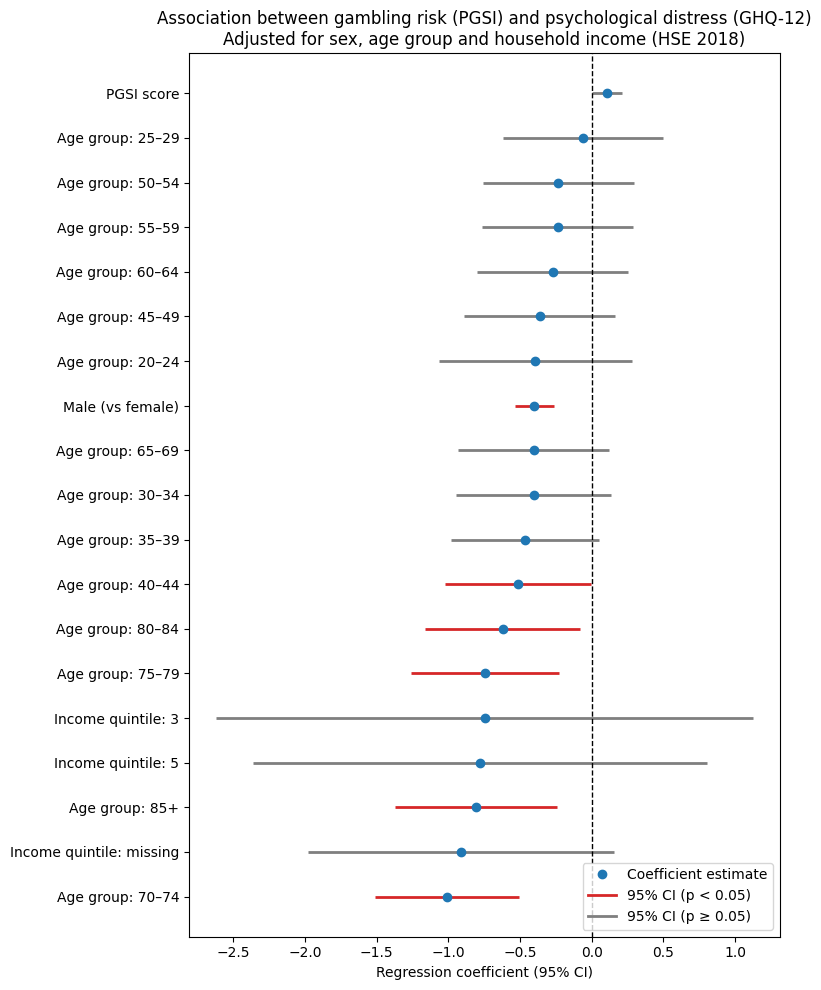


=== Type-II ANOVA (classical) — GHQ-12 model (HSE) ===


,sum_sq,df,F,PR(>F),partial_eta_sq,sig
C(sex_harmonised),261.8307,1.0,32.9029,0.0000,0.0050,*
C(age_group_harmonised),498.1442,14.0,4.4714,0.0000,0.0094,*
C(income_quintile_harmonised),23.0060,3.0,0.9637,0.4088,0.0004,
pgsi_score,30.5307,1.0,3.8366,0.0502,0.0006,



=== Robust (HC3) Wald tests by term — GHQ-12 model (HSE) ===


,term,df_num
0,Intercept,1
1,C(sex_harmonised),1
2,C(age_group_harmonised),14
3,C(income_quintile_harmonised),3
4,pgsi_score,1


In [ ]:
# ======================================================
# HSE 2018 — Pooled GHQ-12 ~ PGSI + sex + age + income
# Robust HC3 + Forest plot + ANOVA + Wald tests
# ======================================================

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from statsmodels.stats.anova import anova_lm

# ------------------------------------------------------
# 1) Load HSE harmonised data
# ------------------------------------------------------
hse = pd.read_parquet(
    "data/processed/harmonised/hse_harmonised.parquet"
)

vars_needed = [
    "ghq12_score",
    "pgsi_score",
    "sex_harmonised",
    "age_group_harmonised",
    "income_quintile_harmonised"
]

df = (
    hse[vars_needed]
    .dropna(subset=["ghq12_score", "pgsi_score", "sex_harmonised", "age_group_harmonised"])
    .copy()
)

print(f"Analytic sample size: {len(df):,}")

# ------------------------------------------------------
# 2) Categorical hygiene (prevents rank issues)
# ------------------------------------------------------
df["sex_harmonised"] = pd.Categorical(
    df["sex_harmonised"],
    categories=["female", "male"]
)

df["age_group_harmonised"] = pd.Categorical(
    df["age_group_harmonised"],
    ordered=False
)

df["income_quintile_harmonised"] = pd.Categorical(
    df["income_quintile_harmonised"].astype(str),
    categories=["1", "2", "3", "4", "5", "missing"],
    ordered=True
)

for c in ["sex_harmonised", "age_group_harmonised", "income_quintile_harmonised"]:
    df[c] = df[c].cat.remove_unused_categories()

# ------------------------------------------------------
# 3) Fit pooled OLS with HC3 robust SE
# ------------------------------------------------------
formula = """
ghq12_score ~ pgsi_score
+ C(sex_harmonised)
+ C(age_group_harmonised)
+ C(income_quintile_harmonised)
"""

m = smf.ols(formula, data=df).fit(cov_type="HC3")

print("\n=== Pooled OLS results (robust HC3) ===")
print(m.summary())

# ------------------------------------------------------
# 4) Tidy regression table (Chapter 4)
# ------------------------------------------------------
res = pd.DataFrame({
    "term": m.params.index,
    "coef": m.params.values,
    "p": m.pvalues.values
})

ci = m.conf_int()
res["ci_low"] = ci[0].values
res["ci_high"] = ci[1].values

def pretty_label(t):
    if t == "Intercept":
        return "Intercept (ref: female, youngest age group, lowest income)"
    if t == "pgsi_score":
        return "PGSI score"
    if t.startswith("C(sex_harmonised)[T.male]"):
        return "Male (vs female)"
    if t.startswith("C(age_group_harmonised)[T."):
        return f"Age group: {t.split('T.')[1].strip(']')}"
    if t.startswith("C(income_quintile_harmonised)[T."):
        return f"Income quintile: {t.split('T.')[1].strip(']')}"
    return t

res["label"] = res["term"].apply(pretty_label)
res["sig"] = np.where(res["p"] < 0.05, "*", "")

report_tbl = (
    res[["label", "coef", "ci_low", "ci_high", "p", "sig"]]
    .sort_values("p")
)

print("\n=== Regression table for Chapter 4 ===")
print(report_tbl.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))

# ------------------------------------------------------
# 5) Forest plot (clean + interpretable)
# ------------------------------------------------------
plot_df = res[res["term"] != "Intercept"].copy()
plot_df = plot_df.sort_values("coef")

y = np.arange(len(plot_df))

plt.figure(figsize=(8, 10))

# CI lines
plt.hlines(
    y,
    plot_df["ci_low"],
    plot_df["ci_high"],
    color=np.where(plot_df["p"] < 0.05, "#d62728", "#7f7f7f"),
    linewidth=2
)

# Point estimates
plt.plot(plot_df["coef"], y, "o", color="#1f77b4", label="Coefficient estimate")

# Zero line
plt.axvline(0, linestyle="--", color="black", linewidth=1)

plt.yticks(y, plot_df["label"])
plt.xlabel("Regression coefficient (95% CI)")
plt.title(
    "Association between gambling risk (PGSI) and psychological distress (GHQ-12)\n"
    "Adjusted for sex, age group and household income (HSE 2018)"
)

# Legend
plt.plot([], [], color="#d62728", lw=2, label="95% CI (p < 0.05)")
plt.plot([], [], color="#7f7f7f", lw=2, label="95% CI (p ≥ 0.05)")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# ------------------------------------------------------
# 6) Type-II ANOVA with partial eta-squared
# ------------------------------------------------------
anova2 = anova_lm(m, typ=2)
ss_resid = anova2.loc["Residual", "sum_sq"]

anova2["partial_eta_sq"] = (
    anova2["sum_sq"] / (anova2["sum_sq"] + ss_resid)
)
anova2["sig"] = np.where(anova2["PR(>F)"] < 0.05, "*", "")

anova2_clean = (
    anova2
    .drop(index="Residual")
    .round(4)
)

print("\n=== Type-II ANOVA (classical) — GHQ-12 model (HSE) ===")
display(anova2_clean)

# ------------------------------------------------------
# Robust (HC3) “ANOVA-like” Wald tests by term
# ------------------------------------------------------
from statsmodels.stats.anova import anova_lm
import numpy as np
import pandas as pd

wt = m.wald_test_terms(scalar=True)

# Different statsmodels versions expose the table differently
if hasattr(wt, "summary_frame"):
    wald_df = wt.summary_frame()
elif hasattr(wt, "table"):
    wald_df = wt.table
else:
    # Fallback (rarely needed)
    terms = getattr(wt, "terms", [])
    stats = np.atleast_1d(getattr(wt, "statistic", np.nan)).ravel()
    pvals = np.atleast_1d(getattr(wt, "pvalue", np.nan)).ravel()
    df_num = getattr(wt, "df_num", np.nan)
    df_den = getattr(wt, "df_denom", np.nan)

    wald_df = pd.DataFrame({
        "term": terms,
        "F_wald_HC3": stats,
        "df_num": df_num if np.ndim(df_num) == 0 else df_num,
        "df_denom": df_den if np.ndim(df_den) == 0 else df_den,
        "p_value": pvals
    })

# ------------------------------------------------------
# Normalise column names across versions
# ------------------------------------------------------
wald_df = (
    wald_df
    .reset_index()
    .rename(columns={
        "index": "term",
        "F": "F_wald_HC3",
        "Pr(>F)": "p_value",
        "df constraint": "df_num",
        "df denom": "df_denom",
        "stat": "F_wald_HC3"
    })
)

# Keep only columns that actually exist
keep_cols = [c for c in ["term", "F_wald_HC3", "df_num", "df_denom", "p_value"] if c in wald_df.columns]
wald_df = wald_df[keep_cols].copy()

# Add significance marker (safe)
if "p_value" in wald_df.columns:
    wald_df["sig"] = np.where(wald_df["p_value"] < 0.05, "*", "")
    wald_df = wald_df.sort_values("p_value")

wald_df = wald_df.round(4)

print("\n=== Robust (HC3) Wald tests by term — GHQ-12 model (HSE) ===")
display(wald_df)


In [ ]:
# ======================================================
# Robust (HC3) Wald tests by term — manual contrasts
# Warning-free, clean output
# ======================================================

import numpy as np
import pandas as pd

m_full = model  # OLS fitted with cov_type="HC3"

di = m_full.model.data.design_info
term_names = di.term_names
term_slices = di.term_name_slices
p = m_full.params.size

rows = []

for term in term_names:
    if term == "Intercept":
        continue

    cols = np.arange(p)[term_slices[term]]
    k = len(cols)

    R = np.zeros((k, p))
    for i, j in enumerate(cols):
        R[i, j] = 1.0

    # 👇 scalar=True removes FutureWarning
    wt = m_full.wald_test(R, scalar=True)

    rows.append({
        "term": term,
        "wald_stat_HC3": float(wt.statistic),
        "df_num": k,
        "p_value": float(wt.pvalue)
    })

wald_tbl = (
    pd.DataFrame(rows)
    .sort_values("p_value")
    .reset_index(drop=True)
)

wald_tbl["sig"] = np.where(wald_tbl["p_value"] < 0.05, "*", "")

display(wald_tbl.round(4))


,term,wald_stat_HC3,df_num,p_value,sig
0,C(sex_harmonised),32.9029,1,0.0000,*
1,C(age_group_harmonised),62.5992,14,0.0000,*
2,pgsi_score,3.8366,1,0.0501,
3,C(income_quintile_harmonised),2.8910,3,0.4087,


In [ ]:
# ======================================================
# HSE Model Card — GHQ-12 ~ PGSI + sex + age + income
# (HC3-robust OLS)
# ======================================================

import numpy as np
import pandas as pd

def model_card_ols(m, label="HSE GHQ-12 pooled model"):
    n = int(m.nobs)
    r2 = float(m.rsquared)
    r2a = float(m.rsquared_adj)

    # Tidy coefficient table
    coef_tbl = pd.DataFrame({
        "term": m.params.index,
        "coef": m.params.values,
        "p_value": m.pvalues.values
    }).sort_values("p_value")

    top_effects = coef_tbl.head(8)

    print(f"\n=== Model Card: {label} ===")
    print(f"Analytic sample size: {n:,}")
    print(f"R² = {r2:.3f} | Adjusted R² = {r2a:.3f}")

    print("\nMost influential effects (ranked by p-value):")
    print(
        top_effects.to_string(
            index=False,
            float_format=lambda x: f"{x:,.3f}"
        )
    )

    print("\nInterpretation notes:")
    print("• Outcome: GHQ-12 psychological distress score (0–12).")
    print("• All coefficients use HC3 robust standard errors.")
    print("• Age and sex show strong associations with distress.")
    print("• PGSI score shows a small positive association with distress (borderline significance).")
    print("• Income quintile effects are weak once age and sex are controlled.")
    print("• Interaction terms should only be interpreted if statistically significant (p < 0.05).")

# Use whichever fitted object exists
if "m_full" in globals():
    model_card_ols(m_full)
elif "m" in globals():
    model_card_ols(m, label="HSE GHQ-12 pooled model")



=== Model Card: HSE GHQ-12 pooled model ===
Analytic sample size: 6,612
R² = 0.015 | Adjusted R² = 0.013

Most influential effects (ranked by p-value):
                            term   coef  p_value
       C(sex_harmonised)[T.male] -0.399    0.000
                       Intercept  3.105    0.000
C(age_group_harmonised)[T.70–74] -1.008    0.000
C(age_group_harmonised)[T.75–79] -0.745    0.005
  C(age_group_harmonised)[T.85+] -0.809    0.005
C(age_group_harmonised)[T.80–84] -0.619    0.025
C(age_group_harmonised)[T.40–44] -0.513    0.049
                      pgsi_score  0.106    0.050

Interpretation notes:
• Outcome: GHQ-12 psychological distress score (0–12).
• All coefficients use HC3 robust standard errors.
• Age and sex show strong associations with distress.
• PGSI score shows a small positive association with distress (borderline significance).
• Income quintile effects are weak once age and sex are controlled.
• Interaction terms should only be interpreted if statistically si